In [1]:
! sudo pip install -U bltk
! pip install -U bnlp_toolkit
! pip install inltk
! pip install banglanltk

     |████████████████████████████████| 17.4 MB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 301 kB 69.1 MB/s eta 0:00:01
     |████████████████████████████████| 1.5 MB 65.5 MB/s eta 0:00:01
     |████████████████████████████████| 17.3 MB 56.9 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 58.8 MB/s eta 0:00:01
     |████████████████████████████████| 34.5 MB 65.7 MB/s eta 0:00:01
    ERROR: Command errored out with exit status 1:
     command: /usr/bin/python3 -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-i3ta8yjd/sklearn/setup.py'"'"'; __file__='"'"'/tmp/pip-install-i3ta8yjd/sklearn/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' egg_info --egg-base /tmp/pip-install-i3ta8yjd/sklearn/pip-egg-info
         cwd: /tmp/pip-install-i3ta8yjd/sklearn/
    Complete output (15 lines):
    The 'sklearn' PyPI p

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re 
from wordcloud import WordCloud
import string

from wordcloud import WordCloud
import matplotlib.pylab as plt
from PIL import Image, ImageTk
from wordcloud.wordcloud import STOPWORDS
stopwords=set(STOPWORDS)
from collections import Counter
from PIL import Image, ImageDraw, ImageFont

from nltk.tokenize import word_tokenize
from wordcloud import STOPWORDS
import nltk
import string
import seaborn as sns
from tensorflow.python.keras.layers.pooling import MaxPool1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Dense,Embedding,LSTM,Conv1D,MaxPool1D 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from nltk.probability import FreqDist

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')



2024-04-23 06:07:35.793660: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-23 06:07:35.793770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-23 06:07:35.908319: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# read data

In [3]:
df1=pd.read_csv("/kaggle/input/bangla-and-english-fake-news-dataset/final_en.csv")
df2=pd.read_csv("/kaggle/input/bangla-and-english-fake-news-dataset/final_bn_data.csv")

In [4]:
mask=np.array(Image.open("/kaggle/input/bangla-and-english-fake-news-dataset/twitter.png"))
myfontpath="/kaggle/input/bangla-and-english-fake-news-dataset/Ador Noirrit Web.otf"

# English Data Analysis

In [5]:
df1.head()

,title,text,lebel
0,Trump backs off praise of Russia's Putin after...,"HENDERSON, Nev. (Reuters) - U.S. Republican pr...",1
1,Trump's funding request for U.S. border wall h...,WASHINGTON (Reuters) - President Donald Trump’...,1
2,"As Votes For Trump Went Up, Canada’s Immigrat...","Well, sad to say, it s a sure chance the next ...",0
3,"U.S. Navy, shipbuilders ready for Trump's expa...","SIMI VALLEY, Calif. (Reuters) - The U.S. arms ...",1
4,"Trump defends DACA move, urges Congress to ena...",WASHINGTON (Reuters) - President Donald Trump ...,1


In [6]:
df1.isnull().sum()

title    0
text     0
lebel    0
dtype: int64

In [7]:
df1.shape

(10000, 3)

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   10000 non-null  object
 1   text    10000 non-null  object
 2   lebel   10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


In [9]:
df1["lebel"].value_counts()

lebel
1    5000
0    5000
Name: count, dtype: int64

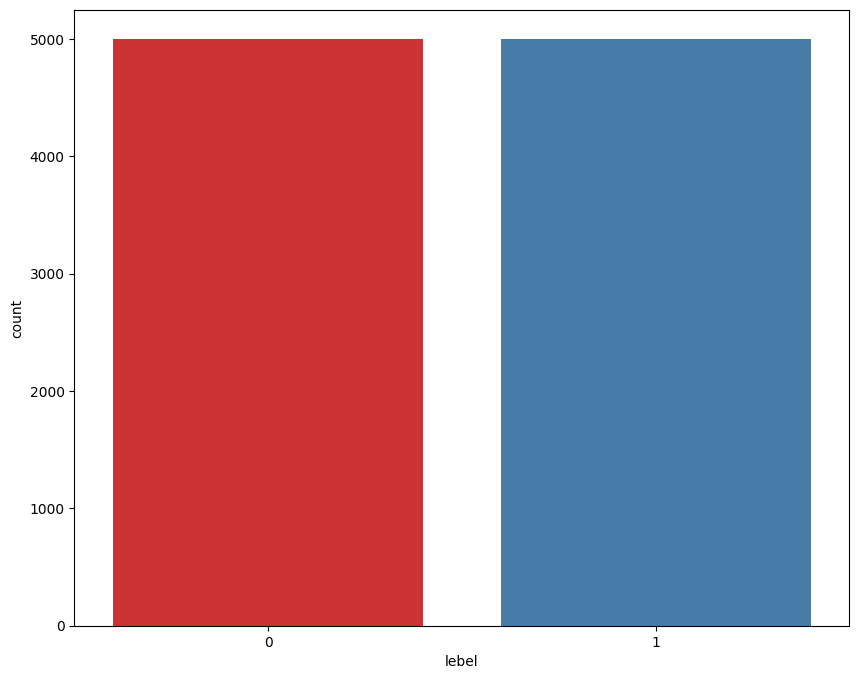

In [10]:
plt.figure(figsize=(10,8))
sns.countplot(x="lebel",data=df1,palette="Set1")
plt.show()

In [11]:
df1["text"]=df1["text"]+df1["title"]

In [12]:
df1.drop(columns="title",axis=1,inplace=True)

In [13]:
def clean_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text()

    # Remove special characters and digits
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove emojis
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    
    # Convert to lowercase
    text = text.lower()

    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    return ' '.join(tokens)

In [14]:
df1["text"]=df1["text"].apply(clean_text)

/tmp/ipykernel_118/3948003542.py:3: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, 'html.parser').get_text()
/tmp/ipykernel_118/3948003542.py:3: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  text = BeautifulSoup(text, 'html.parser').get_text()


In [15]:
df1['number_character']=df1['text'].apply(len)
df1['number_of_words'] = df1['text'].apply(lambda x: len(x.split()))
df1['number_sentence'] = df1['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [16]:
df1.head()

,text,lebel,number_character,number_of_words,number_sentence
0,henderson nev reuters u republican presidentia...,1,2847,392,1
1,washington reuters president donald trump call...,1,1953,264,1
2,well sad say sure chance next president belove...,0,1166,172,1
3,simi valley calif reuters u arms industry read...,1,1762,242,1
4,washington reuters president donald trump defe...,1,506,67,1


In [17]:
df1.describe()

,lebel,number_character,number_of_words,number_sentence
count,10000.000000,10000.000000,10000.000000,10000.0
mean,0.500000,1788.181500,242.930500,1.0
std,0.500025,1435.111621,192.079306,0.0
min,0.000000,28.000000,5.000000,1.0
25%,0.000000,930.000000,130.000000,1.0
50%,0.500000,1585.500000,217.000000,1.0
75%,1.000000,2241.250000,304.000000,1.0
max,1.000000,38023.000000,4988.000000,1.0


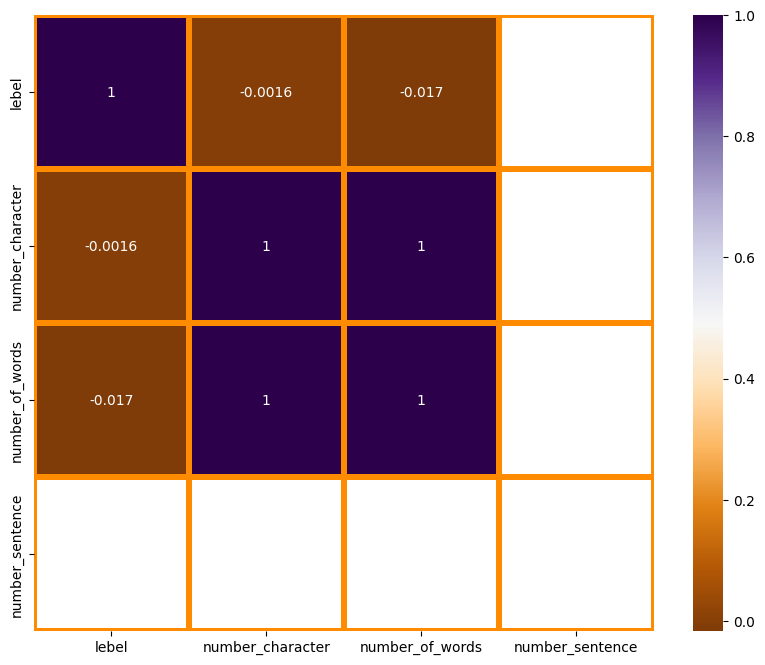

In [18]:
plt.figure(figsize=(10,8))
corr=df1.select_dtypes(["int"]).corr()
sns.heatmap(corr,annot=True,cmap="PuOr",lw=4,linecolor="darkorange")
plt.show()

In [19]:
df1[df1["lebel"]==0][["number_character","number_of_words","number_sentence"]].describe()

,number_character,number_of_words,number_sentence
count,5000.000000,5000.00000,5000.0
mean,1790.529800,246.16340,1.0
std,1642.578856,219.27877,0.0
min,28.000000,5.00000,1.0
25%,1041.000000,146.00000,1.0
50%,1528.000000,212.00000,1.0
75%,2142.000000,293.25000,1.0
max,38023.000000,4988.00000,1.0


In [20]:
df1[df1["lebel"]==1][["number_character","number_of_words","number_sentence"]].describe()

,number_character,number_of_words,number_sentence
count,5000.000000,5000.000000,5000.0
mean,1785.833200,239.697600,1.0
std,1192.235879,160.287909,0.0
min,141.000000,21.000000,1.0
25%,759.000000,102.750000,1.0
50%,1671.500000,224.000000,1.0
75%,2394.000000,321.000000,1.0
max,12433.000000,1692.000000,1.0


# real vs fake data length

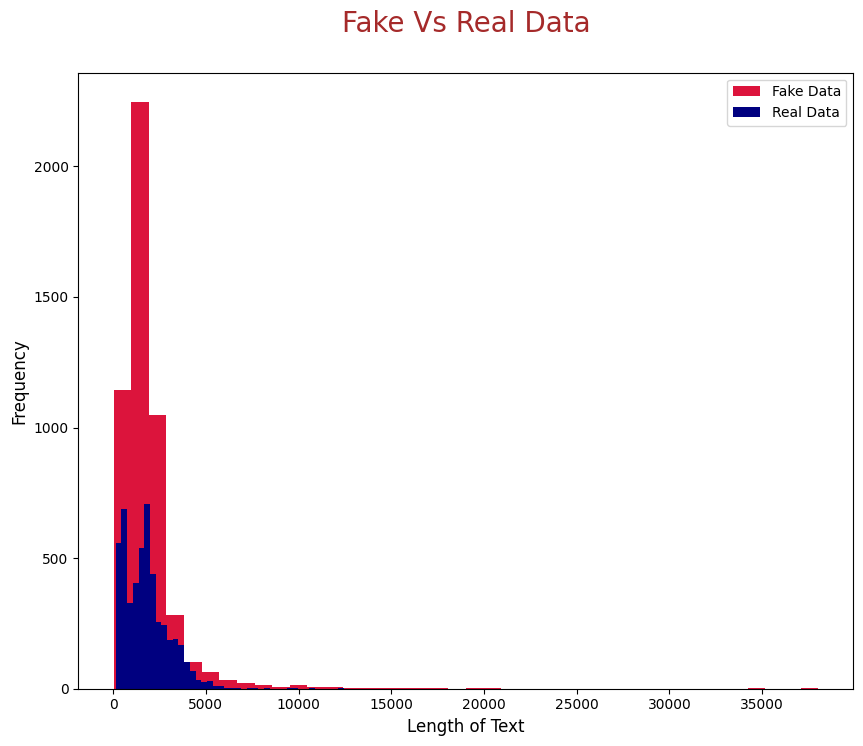

In [21]:
fake_len = df1[df1["lebel"] == 0]["text"].str.len()
real_len = df1[df1["lebel"] == 1]["text"].str.len()

plt.figure(figsize=(10,8))
plt.hist(fake_len, bins=40, label='Fake Data', color="crimson")
plt.hist(real_len, bins=40, label='Real Data', color="navy")
plt.title("Fake Vs Real Data\n", fontsize=20, color="brown")
plt.xlabel("Length of Text", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.legend()
plt.show()

# All data wordcloud

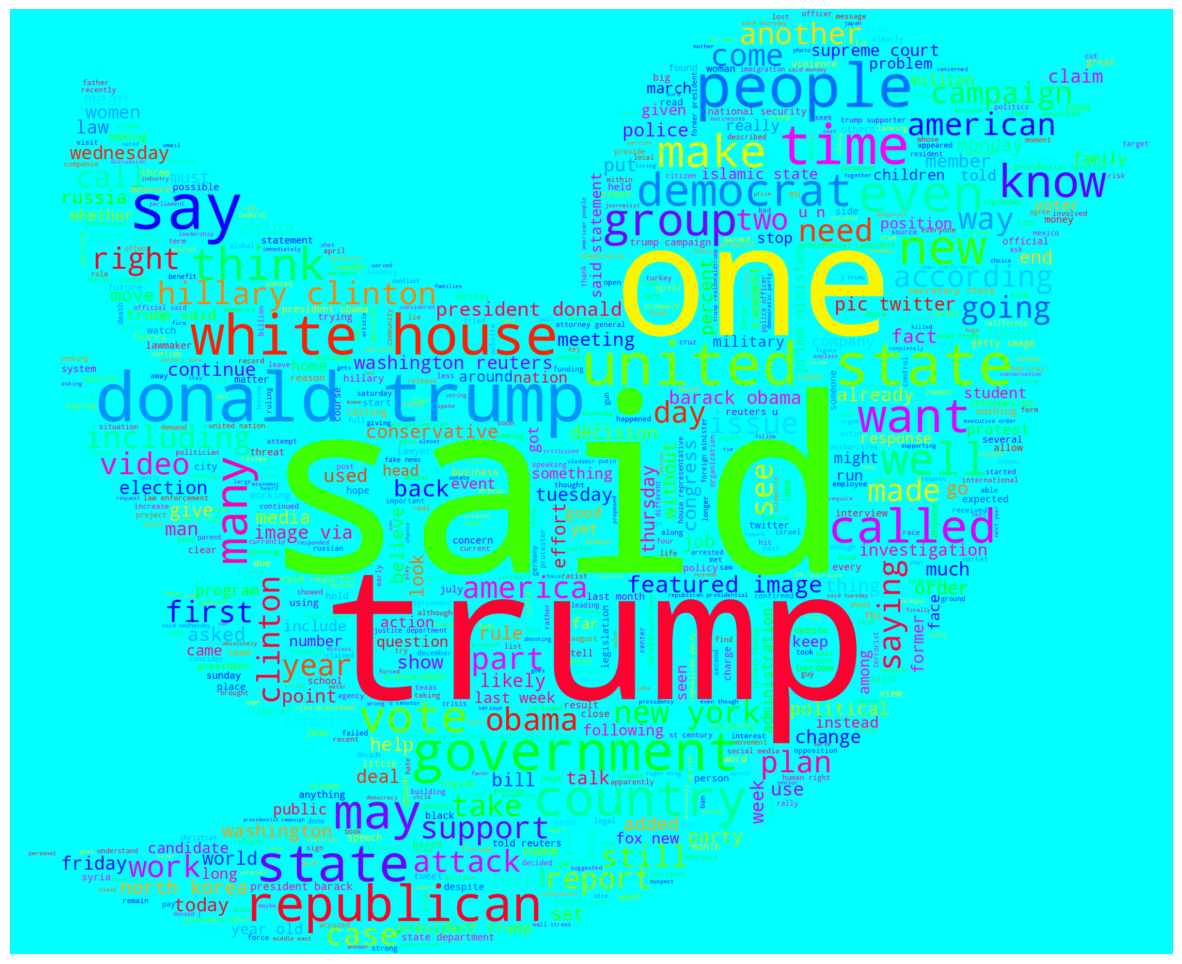

In [22]:
plt.figure(figsize=(15,15))
all_text=" ".join(df1['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='cyan', max_words=800,colormap="hsv",mask=mask).generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Fake Data wordcloud

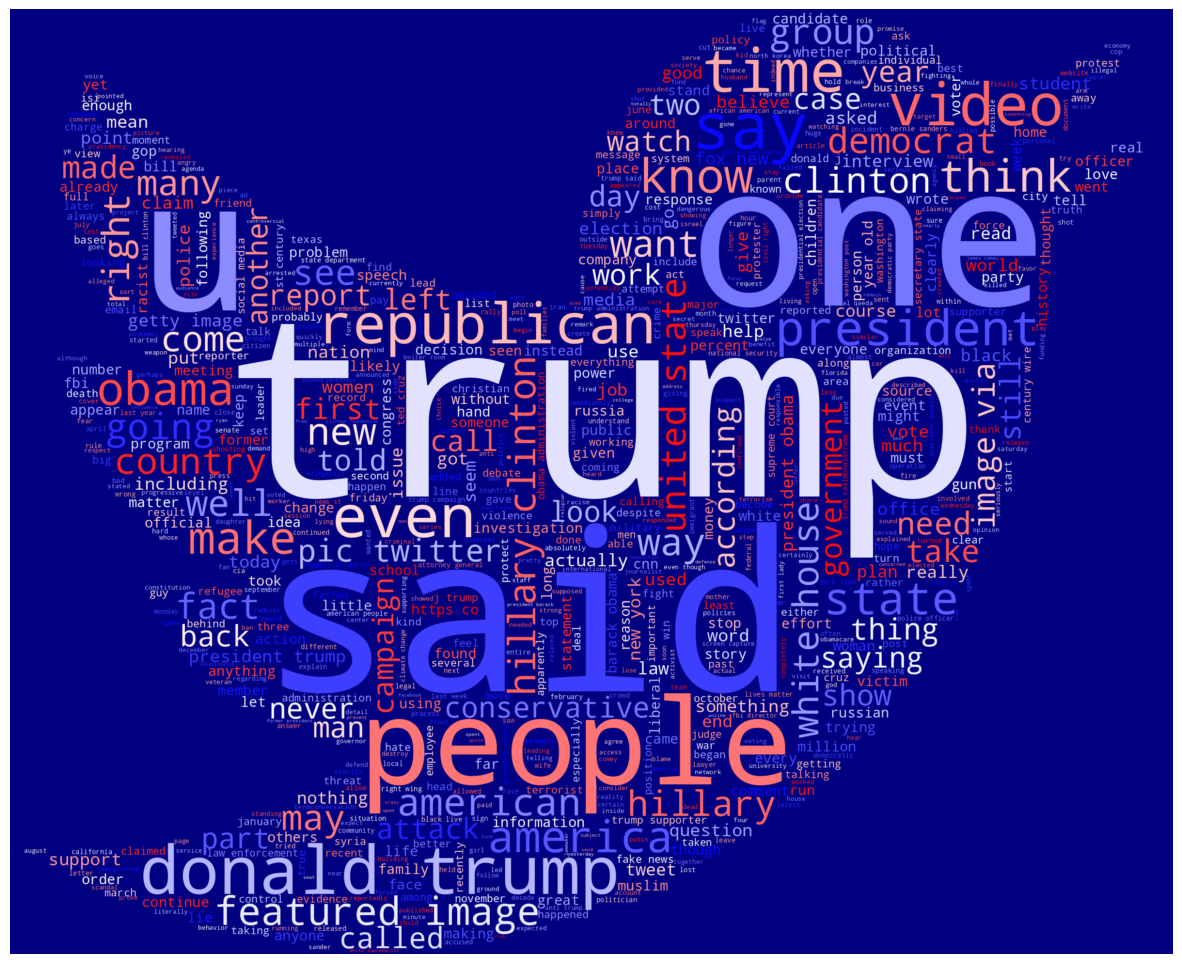

In [23]:
plt.figure(figsize=(15,15))
fake_wordcloud=df1[df1["lebel"]==0]
fake_text=" ".join(fake_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='navy', max_words=800,colormap="bwr",mask=mask).generate(fake_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Real wordcloud

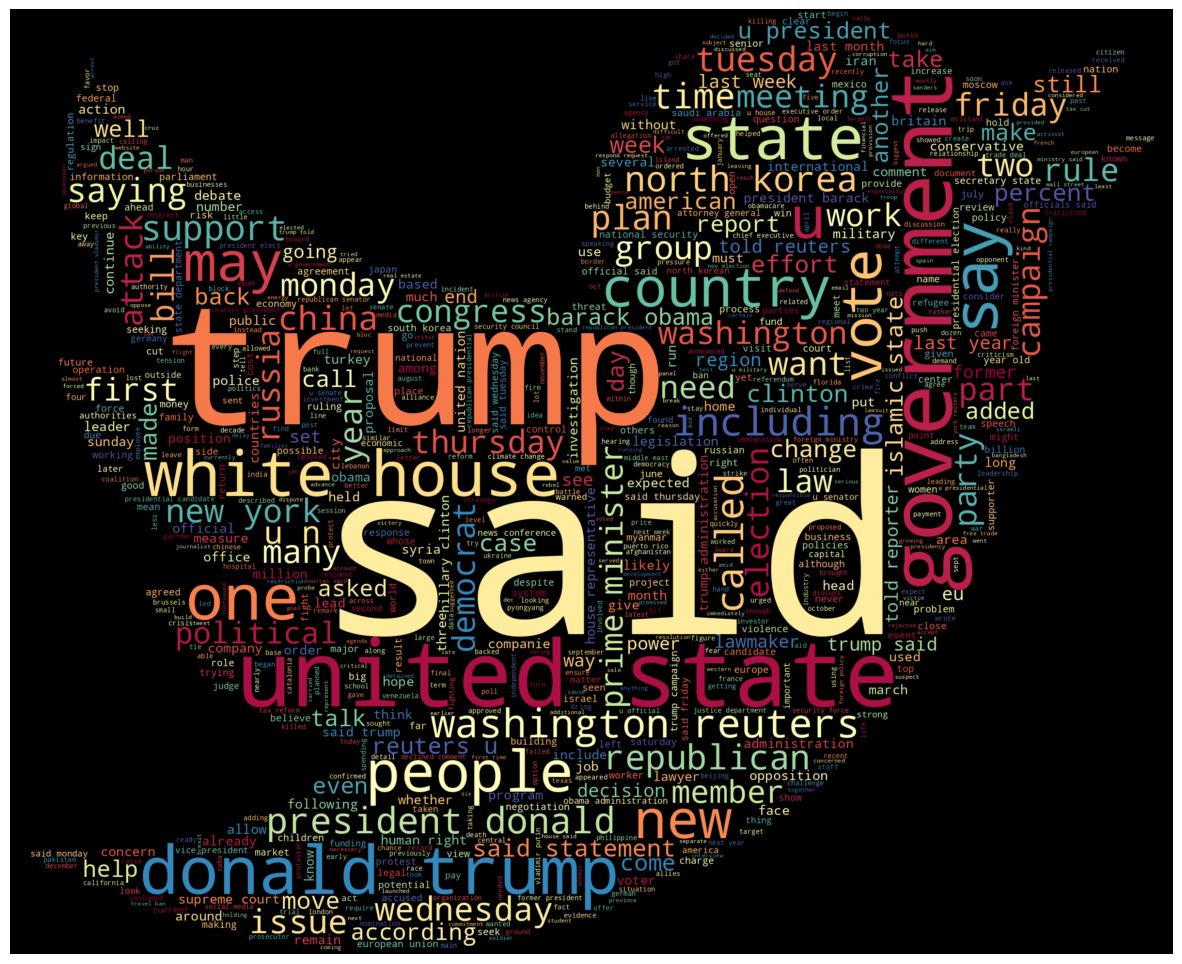

In [24]:
plt.figure(figsize=(15,15))
real_wordcloud=df1[df1["lebel"]==1]
real_text=" ".join(real_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="Spectral",mask=mask).generate(real_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# 30 Most common Words From All Text

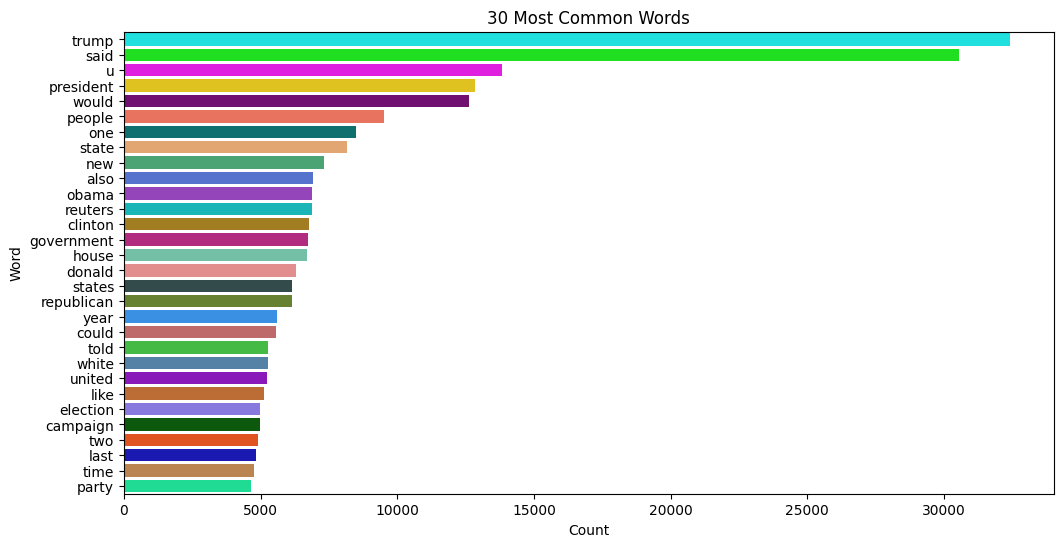

In [25]:
from itertools import chain
data_set =df1["text"].str.split()
all_words = list(chain.from_iterable(data_set))
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

colors = ["cyan", "lime", "magenta", "gold", "purple", "tomato", "teal", "sandybrown", "mediumseagreen",
          "royalblue", "darkorchid", "darkturquoise", "darkgoldenrod", "mediumvioletred", "mediumaquamarine",
          "lightcoral", "darkslategray", "olivedrab", "dodgerblue", "indianred", "limegreen", "steelblue",
          "darkviolet", "chocolate", "mediumslateblue", "darkgreen", "orangered", "mediumblue", "peru", "mediumspringgreen"]

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=colors)
plt.title('30 Most Common Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Fake Text

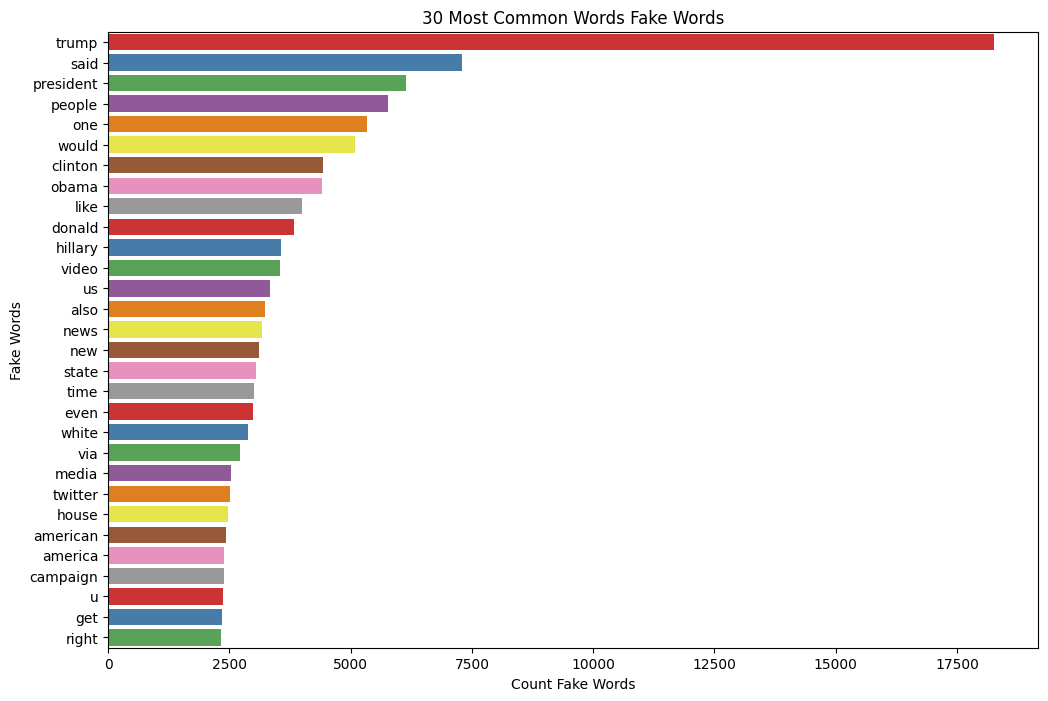

In [26]:
fake_text = df1[df1["lebel"] == 0]
data_set = fake_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Fake Words')
plt.xlabel('Count Fake Words')
plt.ylabel('Fake Words')
plt.show()

# Most Common Words From Real Text

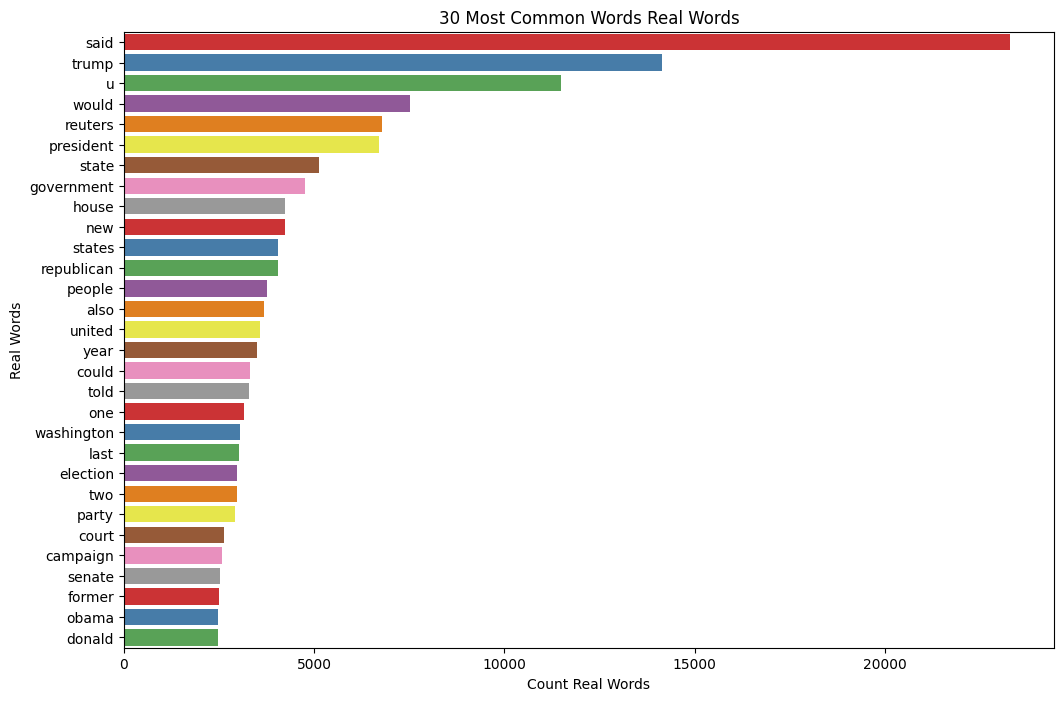

In [27]:
real_text = df1[df1["lebel"] == 1]
data_set = real_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Real Words')
plt.xlabel('Count Real Words')
plt.ylabel('Real Words')
plt.show()

# Character Count

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

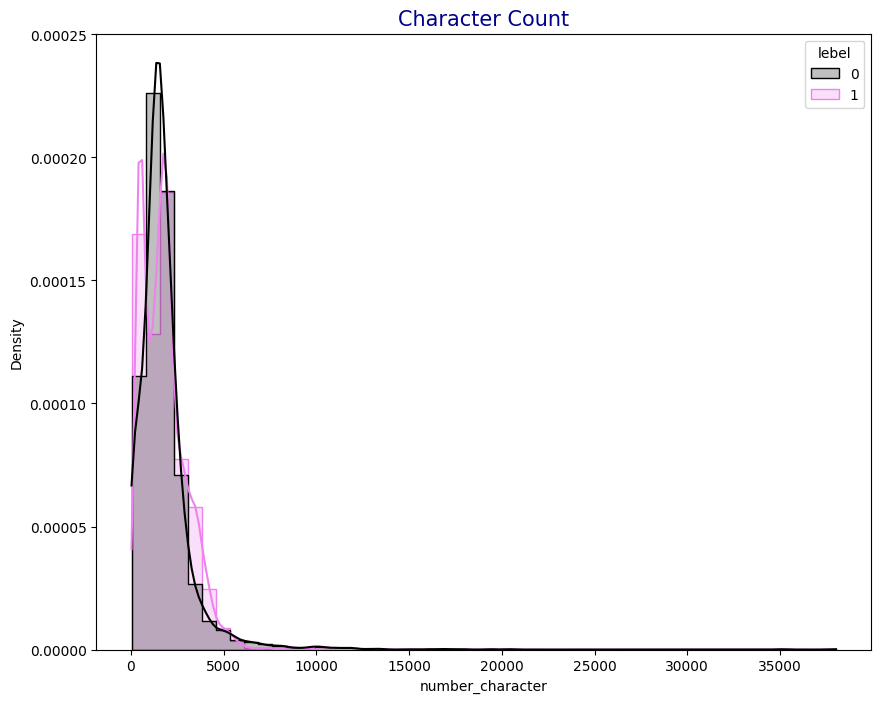

In [28]:
color=["black","violet"]
plt.figure(figsize=(10,8))

sns.histplot(data=df1,x="number_character",palette=color,kde=True,hue="lebel",element="step",stat="density",bins=50)
plt.title("Character Count",fontsize=15,color="darkblue")
plt.show()

# Word Count

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

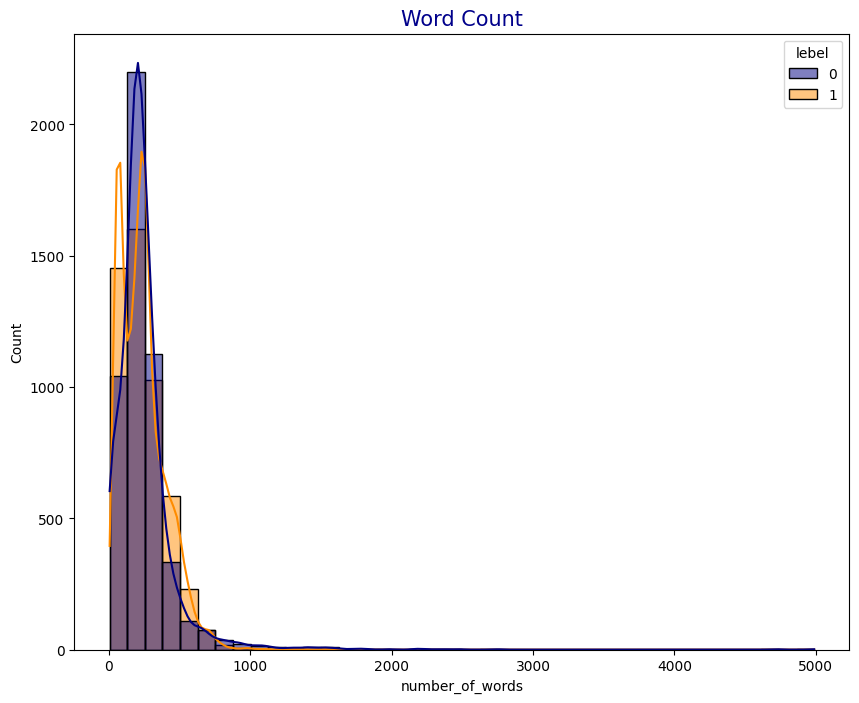

In [29]:
color=["navy","darkorange"]
plt.figure(figsize=(10,8))

sns.histplot(data=df1,x="number_of_words",palette=color,kde=True,hue="lebel",bins=40)
plt.title("Word Count",fontsize=15,color="darkblue")
plt.show()

In [30]:
df1.drop(columns=["number_character","number_of_words","number_sentence"],axis=1,inplace=True)
df1.rename(columns={'lebel': 'label'}, inplace=True)

# Average Sentence Length

In [31]:
avg_len=df1["text"].apply(len)
avg_len=avg_len.mean()
print(f"Average Text Length is : {avg_len:.2f}")

Average Text Length is : 1788.18


In [32]:
df1.head()

,text,label
0,henderson nev reuters u republican presidentia...,1
1,washington reuters president donald trump call...,1
2,well sad say sure chance next president belove...,0
3,simi valley calif reuters u arms industry read...,1
4,washington reuters president donald trump defe...,1


# bangla Data Analysis

In [33]:
df2.head()

,category,headline,content,label
0,National,৮ দিনে ১৮ বিল পাস!,দশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত ...,0.0
1,Sports,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোড,একাদশ জাতীয় সংসদ নির্বাচনকে সামনে রেখে সাংগঠনি...,0.0
2,National,মাদ্রাসায় জোড়া খুন: পরিচালক তিন দিনের রিমান্ডে,গাজীপুরে জোড়া খুন মামলার প্রধান আসামি মাদ্রাসা...,0.0
3,Sports,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশ,সাফ অনূর্ধ্ব-১৮ নারী ফুটবল চ্যাম্পিয়নশিপে নেপা...,1.0
4,National,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধার,কুড়িগ্রাম প্রতিনিধি : কুড়িগ্রাম সদর উপজেলার বে...,1.0


In [34]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14537 entries, 0 to 14536
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  14537 non-null  object 
 1   headline  14537 non-null  object 
 2   content   14537 non-null  object 
 3   label     14537 non-null  float64
dtypes: float64(1), object(3)
memory usage: 454.4+ KB


In [35]:
df2.shape

(14537, 4)

In [36]:
df2.isnull().sum()

category    0
headline    0
content     0
label       0
dtype: int64

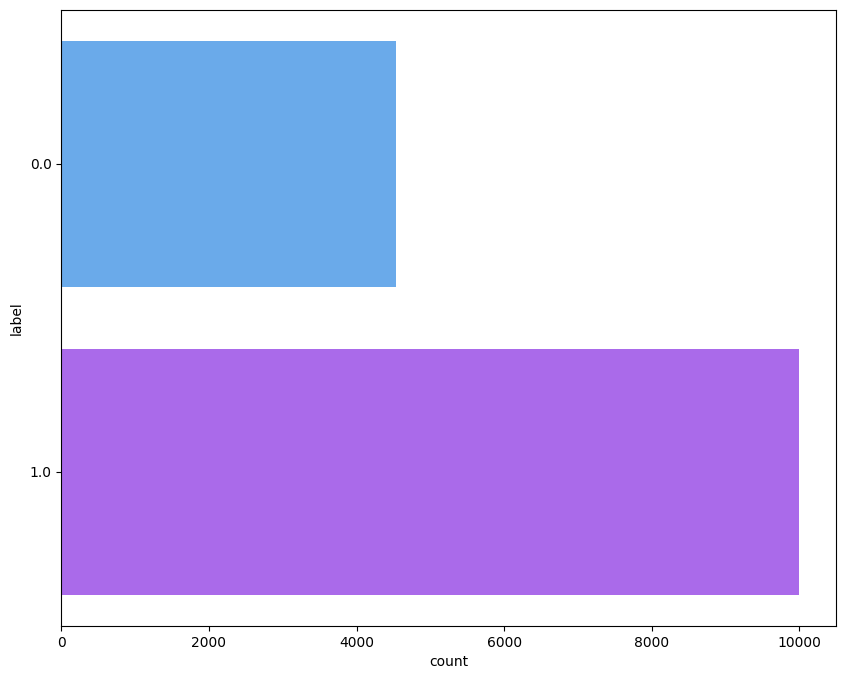

In [37]:
plt.figure(figsize=(10,8))
sns.countplot(data=df2,y="label",palette="cool")
plt.show()

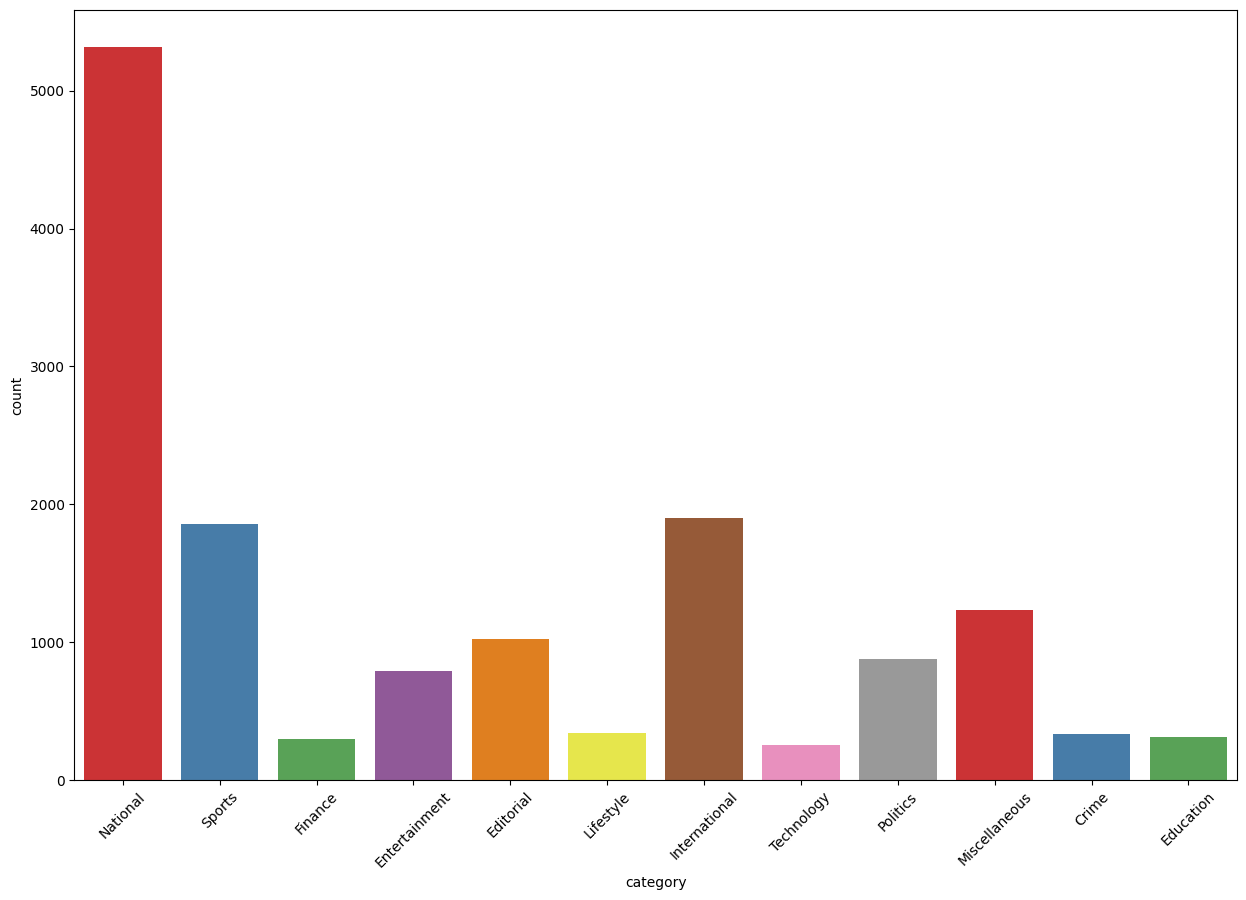

In [38]:
plt.figure(figsize=(15,10))
sns.countplot(x="category",data=df2,palette="Set1")
plt.xticks(rotation=45)
plt.show()

In [39]:
df2["label"]=df2["label"].astype(int)

In [40]:
df2["text"]=df2["headline"]+df2["content"]

In [41]:
df2.drop(columns=["category","headline","content"],axis=1,inplace=True)

In [42]:
df2=df2[["text","label"]]

In [43]:
df2.head()

,text,label
0,৮ দিনে ১৮ বিল পাস!দশম জাতীয় সংসদের মেয়াদ শেষ হ...,0
1,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোডএক...,0
2,মাদ্রাসায় জোড়া খুন: পরিচালক তিন দিনের রিমান্ডে...,0
3,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশসাফ অন...,1
4,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধারকুড়িগ্রাম প...,1


In [44]:
df2["character_count"]=df2["text"].str.len()
df2['word_count'] = df2['text'].str.split().str.len()
df2['sentence_count'] = df2['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

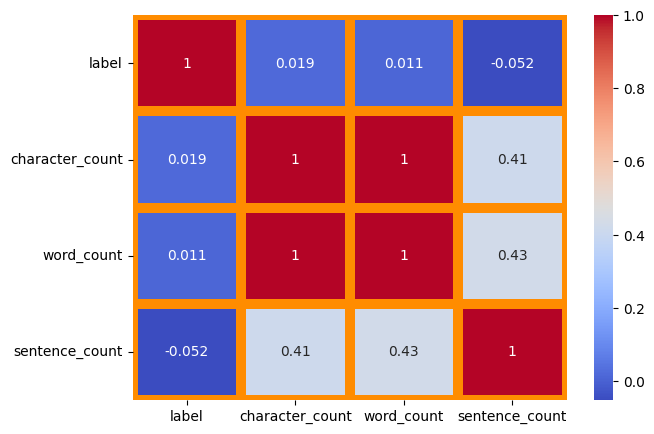

In [45]:
cor=df2[["label","character_count","word_count","sentence_count"]].corr()
plt.figure(figsize=(7,5))
sns.heatmap(cor,annot=True,cmap="coolwarm",linewidths=7, linecolor='darkorange')
plt.show()

# Bangla Data Length

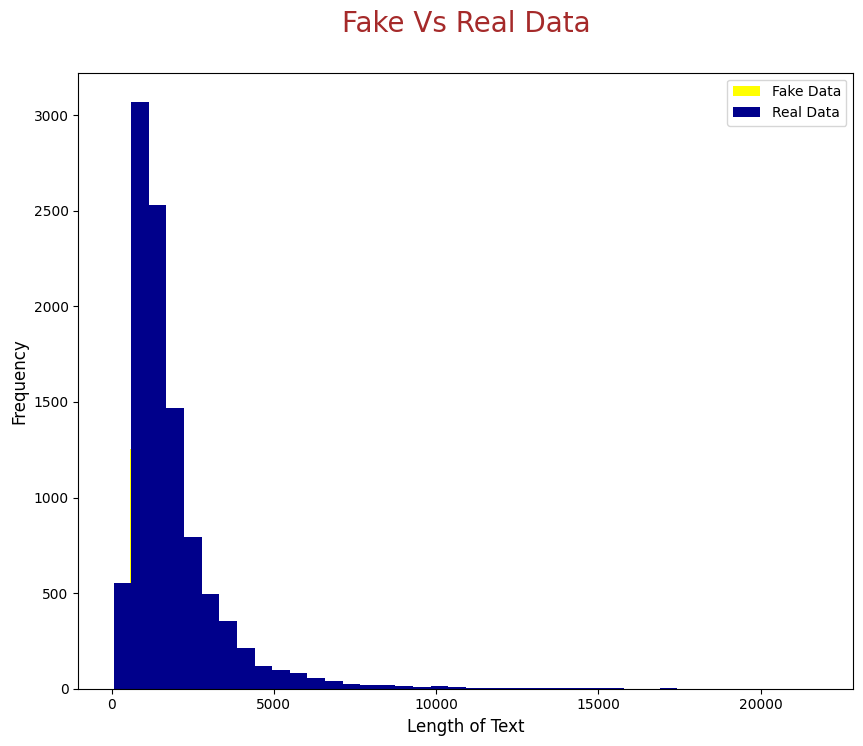

In [46]:
fake_len = df2[df2["label"] == 0]["text"].str.len()
real_len = df2[df2["label"] == 1]["text"].str.len()

plt.figure(figsize=(10,8))
plt.hist(fake_len, bins=40, label='Fake Data', color="yellow")
plt.hist(real_len, bins=40, label='Real Data', color="darkblue")
plt.title("Fake Vs Real Data\n", fontsize=20, color="brown")
plt.xlabel("Length of Text", fontsize=12)  
plt.ylabel("Frequency", fontsize=12)  
plt.legend()
plt.show()

# Clean Bangla text

In [47]:
import re
from bnlp import BengaliCorpus as corpus


from collections import Counter
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from wordcloud import WordCloud
from bs4 import BeautifulSoup
import banglanltk as bn
import string

In [48]:
print(corpus.stopwords)
print("=========================================================================================")
print(corpus.punctuations)
print("=========================================================================================")
print(corpus.letters)
print("=========================================================================================")
print(corpus.digits)
print("=========================================================================================")
print(corpus.vowels)
print("=========================================================================================")

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

In [49]:
def remove_html_tags(text):
    return BeautifulSoup(text, 'html.parser').get_text()

def remove_punctuation(text):
    return ''.join([c for c in text if c not in string.punctuation])

def remove_extra_whitespace_tabs(text):
    pattern = r'^\s*|\s\s*'
    return re.sub(pattern, ' ', text).strip()

def remove_bengali_stopwords(text):
    words = text.split()
    cleaned_words = [word for word in words if word not in corpus.stopwords]
    return ' '.join(cleaned_words)

def cleaning(text):
    text = remove_html_tags(text)
    text = remove_bengali_stopwords(text)
    text = remove_punctuation(text)
    text = remove_extra_whitespace_tabs(text)
    return text

df2["text"]=df2["text"].apply(cleaning)

In [50]:
df2.head()

,text,label,character_count,word_count,sentence_count
0,৮ দিনে ১৮ বিল পাসদশম জাতীয় সংসদের মেয়াদ শেষ হয়...,0,2871,450,1
1,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোডএক...,0,1882,292,1
2,মাদ্রাসায় জোড়া খুন পরিচালক তিন দিনের রিমান্ডেগ...,0,1201,186,5
3,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশসাফ অন...,1,698,96,1
4,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধারকুড়িগ্রাম প...,1,1069,151,2


# All Bangla Data Wordcloud

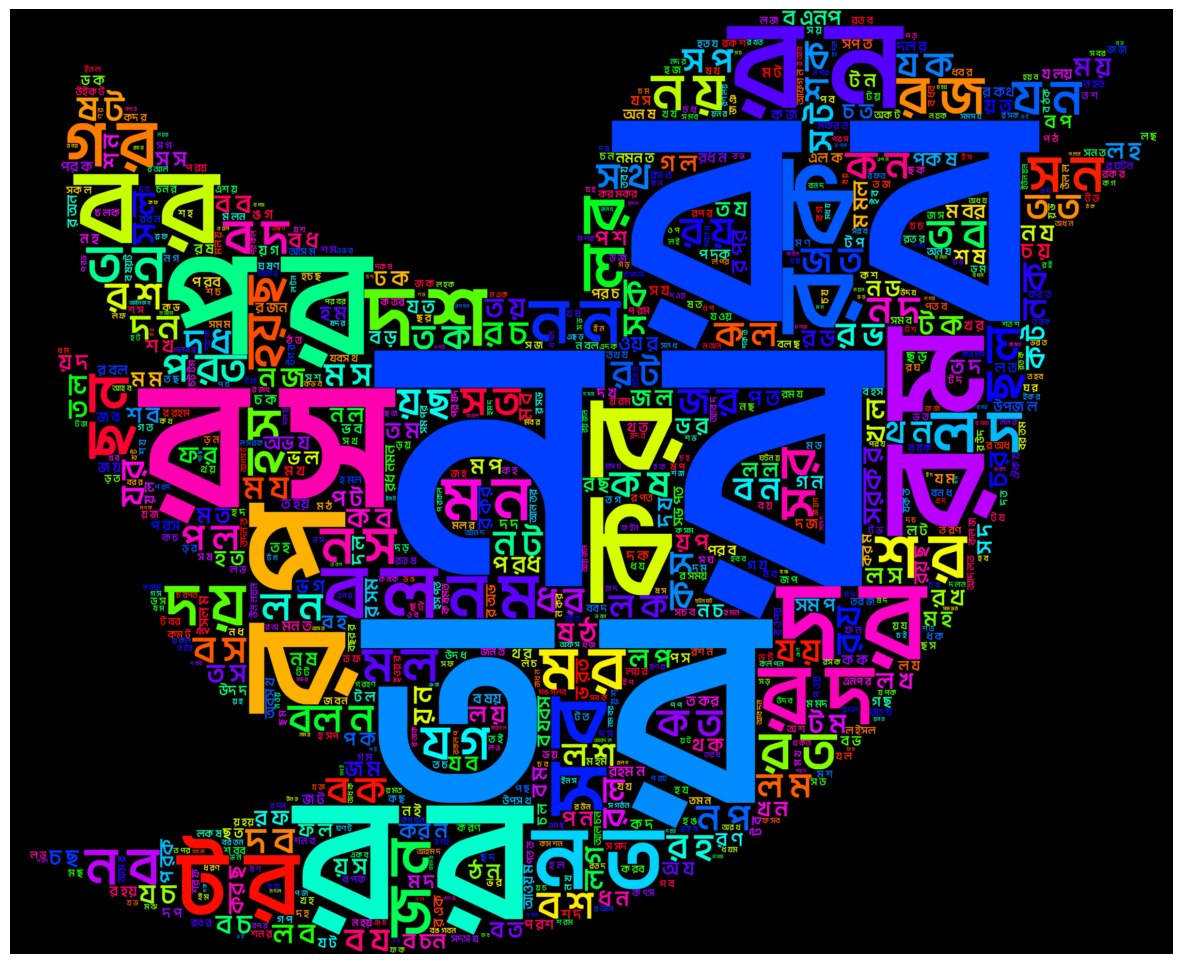

In [51]:
plt.figure(figsize=(15,15))
all_text=" ".join(df2['text'].values.tolist())
wordcloud = WordCloud(width=800,font_path=myfontpath, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="hsv",mask=mask).generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# real bangla wordcloud

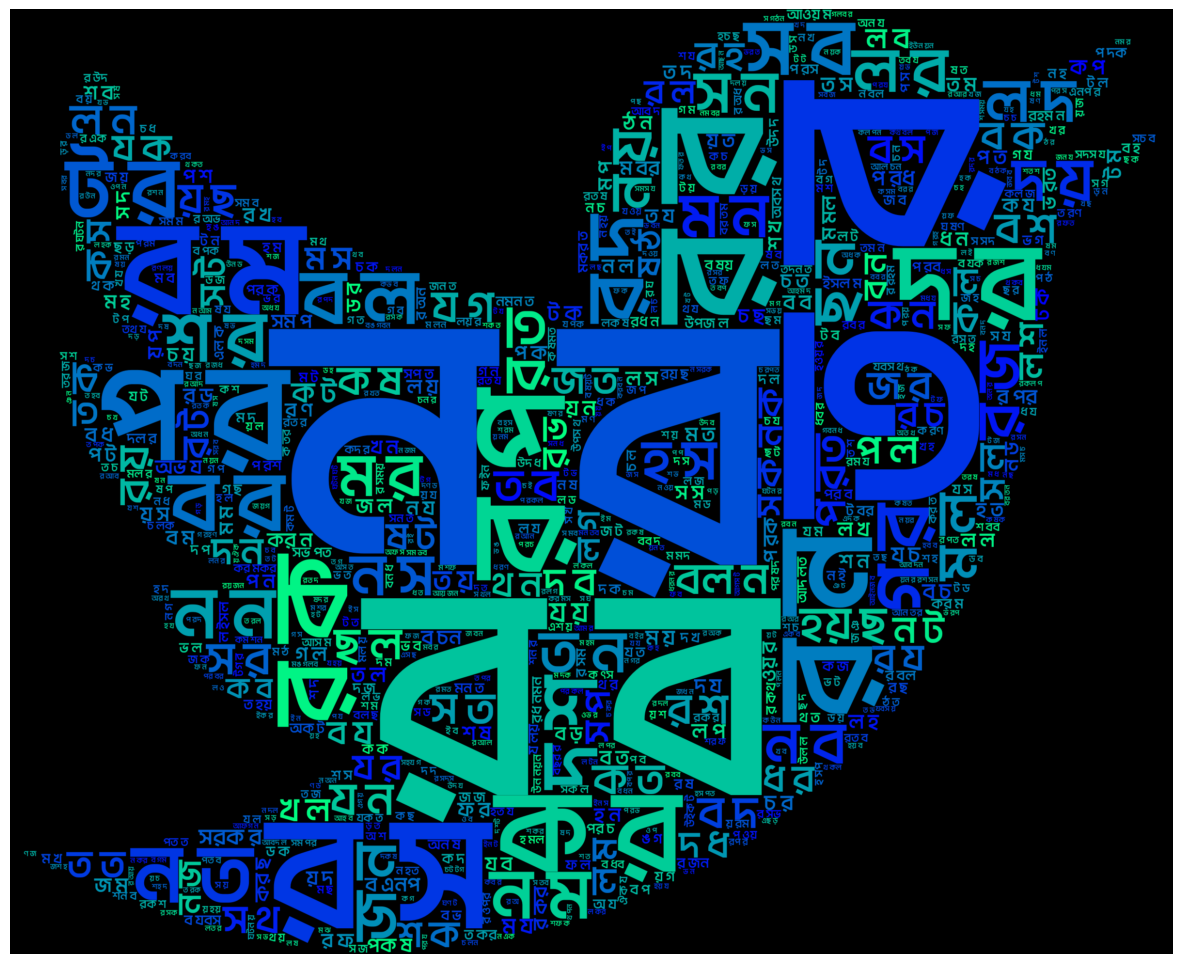

In [52]:
plt.figure(figsize=(15,15))
real_wordcloud=df2[df2["label"]==1]
real_text=" ".join(real_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800,font_path=myfontpath, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="winter",mask=mask).generate(real_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Fake Bangla wordcloud

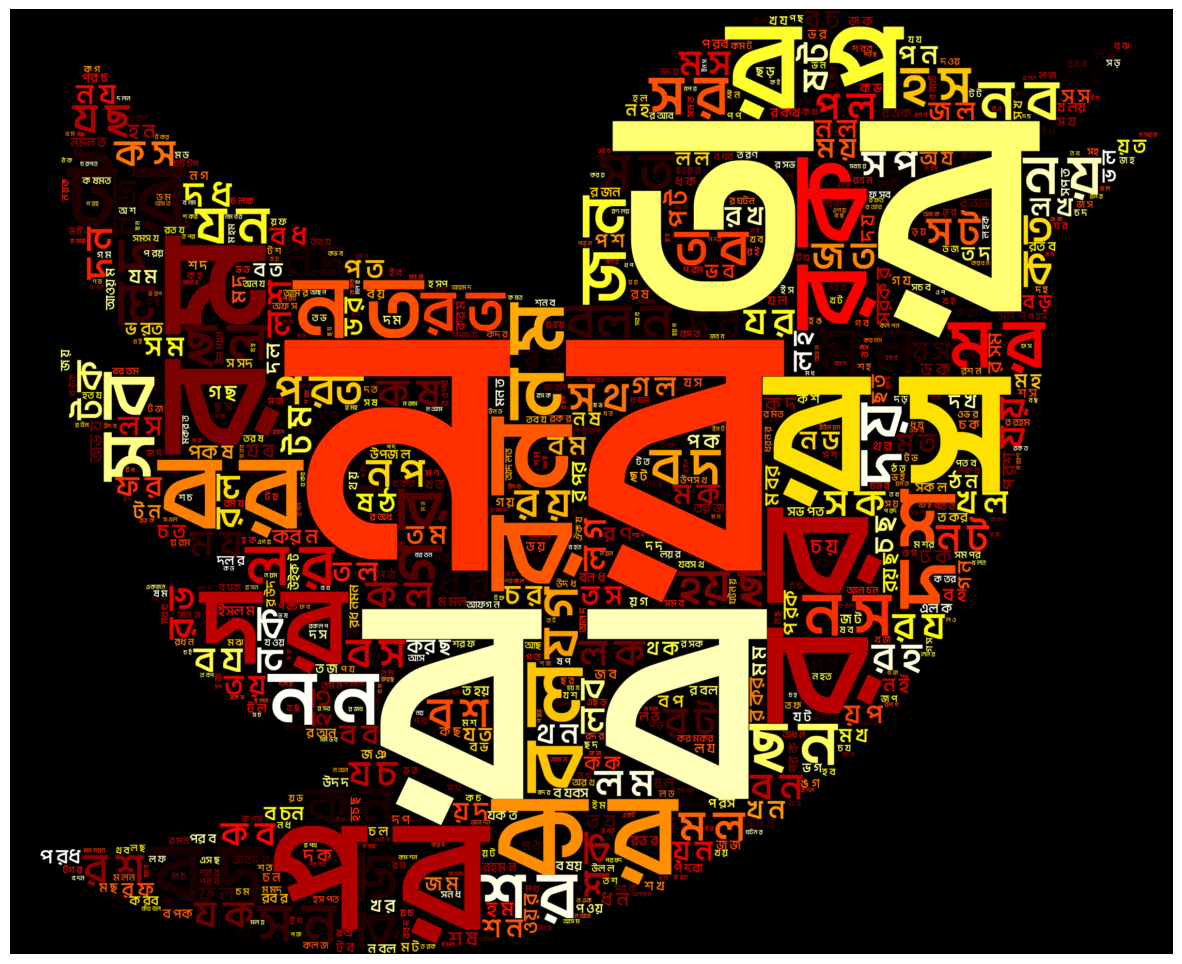

In [53]:
plt.figure(figsize=(15,15))
fake_wordcloud=df2[df2["label"]==0]
fake_text=" ".join(fake_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800,font_path=myfontpath, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="hot",mask=mask).generate(fake_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# 30 Most common Words From Bangla All Text

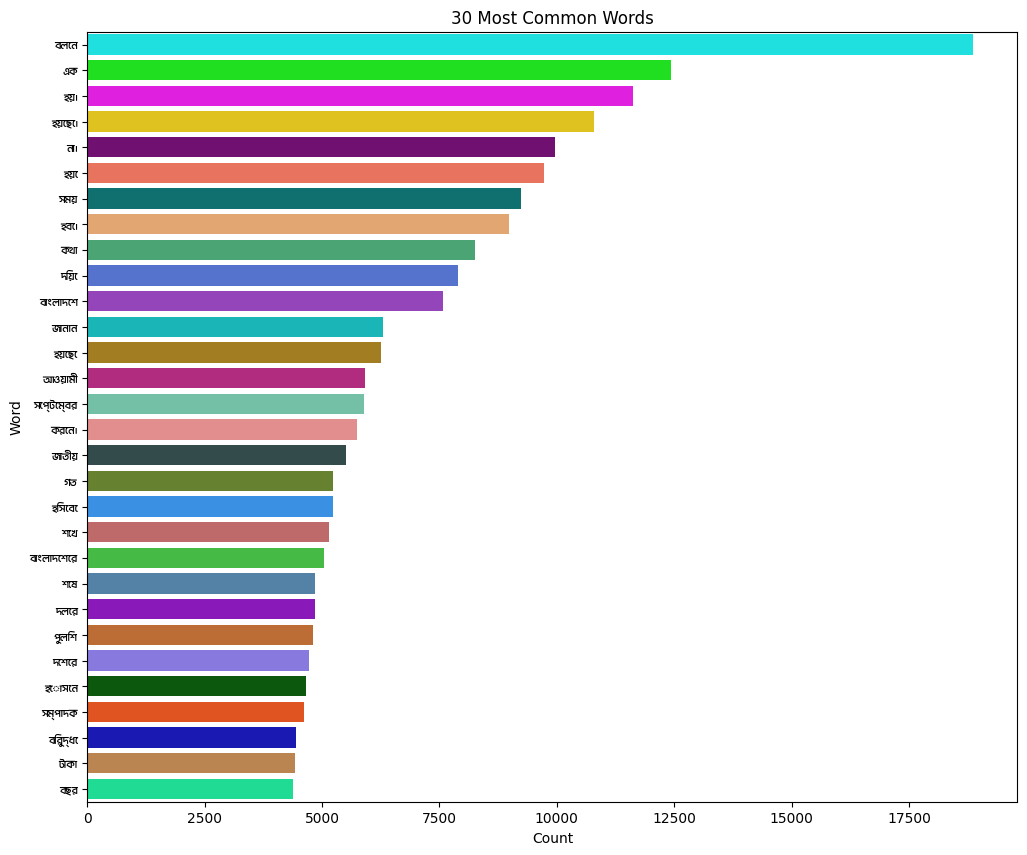

In [54]:

from matplotlib.font_manager import FontProperties


data_set = df2["text"].str.split()
all_words = list(chain.from_iterable(data_set))
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

colors = ["cyan", "lime", "magenta", "gold", "purple", "tomato", "teal", "sandybrown", "mediumseagreen",
          "royalblue", "darkorchid", "darkturquoise", "darkgoldenrod", "mediumvioletred", "mediumaquamarine",
          "lightcoral", "darkslategray", "olivedrab", "dodgerblue", "indianred", "limegreen", "steelblue",
          "darkviolet", "chocolate", "mediumslateblue", "darkgreen", "orangered", "mediumblue", "peru", "mediumspringgreen"]

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=colors)
plt.title('30 Most Common Words')
plt.xlabel('Count')
plt.ylabel('Word')


custom_font = FontProperties(fname='/kaggle/input/bangla-and-english-fake-news-dataset/Ador Noirrit Web.otf')
plt.yticks(fontproperties=custom_font)

plt.show()


# Most Common Words From Fake Text bangla

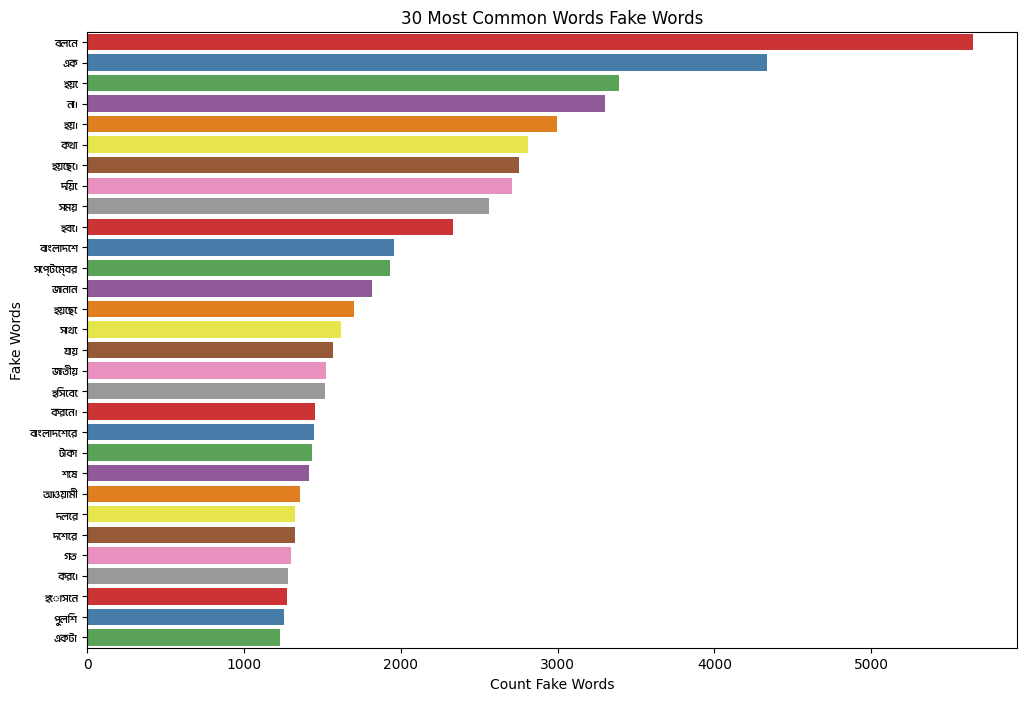

In [55]:
fake_text = df2[df2["label"] == 0]
data_set = fake_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Fake Words')
plt.xlabel('Count Fake Words')
plt.ylabel('Fake Words')
custom_font = FontProperties(fname='/kaggle/input/bangla-and-english-fake-news-dataset/Ador Noirrit Web.otf')
plt.yticks(fontproperties=custom_font)
plt.show()

# Most Common Words From Real Text Bangla

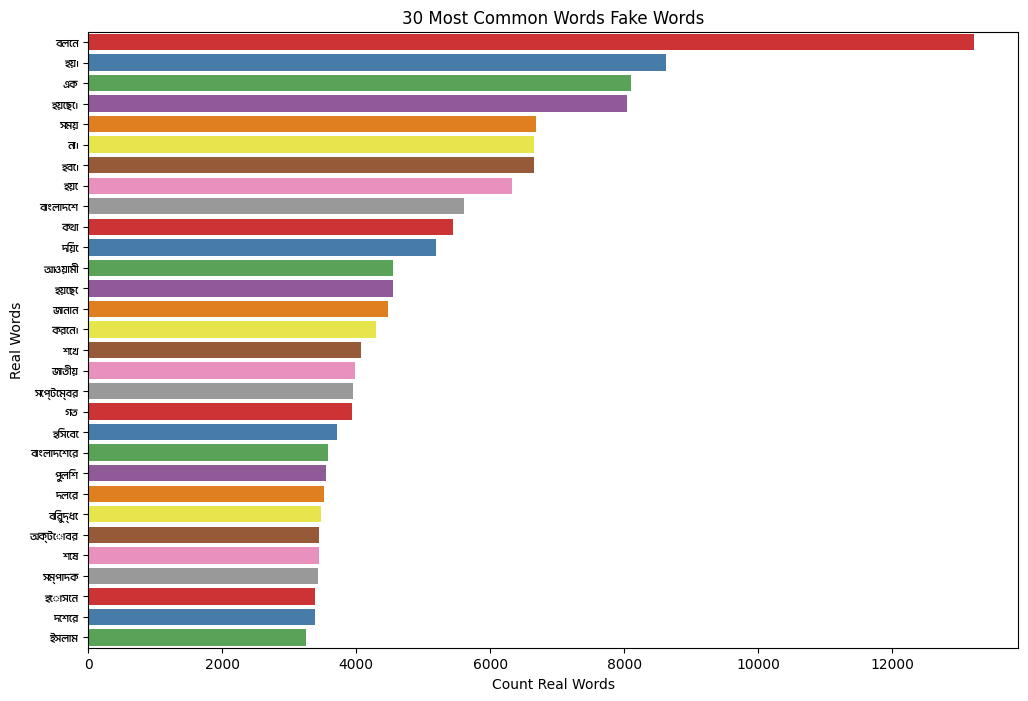

In [56]:
real_text = df2[df2["label"] == 1]
data_set = real_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_common_words,palette="Set1")
plt.title('30 Most Common Words Fake Words')
plt.xlabel('Count Real Words')
plt.ylabel('Real Words')
custom_font = FontProperties(fname='/kaggle/input/bangla-and-english-fake-news-dataset/Ador Noirrit Web.otf')
plt.yticks(fontproperties=custom_font)
plt.show()

# Character Count

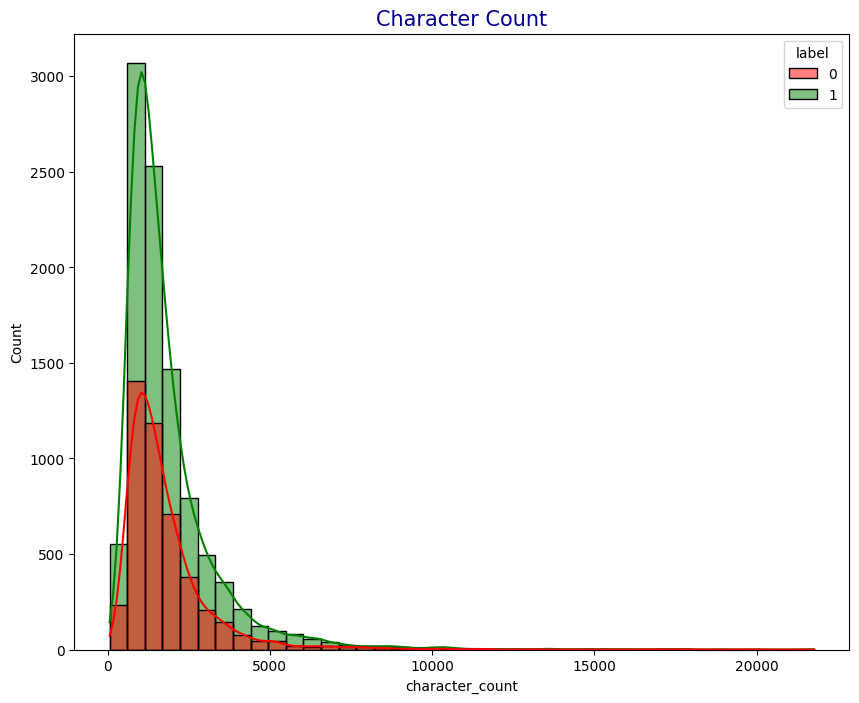

In [57]:
color=["red","green"]
plt.figure(figsize=(10,8))

sns.histplot(data=df2,x="character_count",palette=color,kde=True,hue="label",bins=40)
plt.title("Character Count",fontsize=15,color="darkblue")
plt.show()

# Word Count

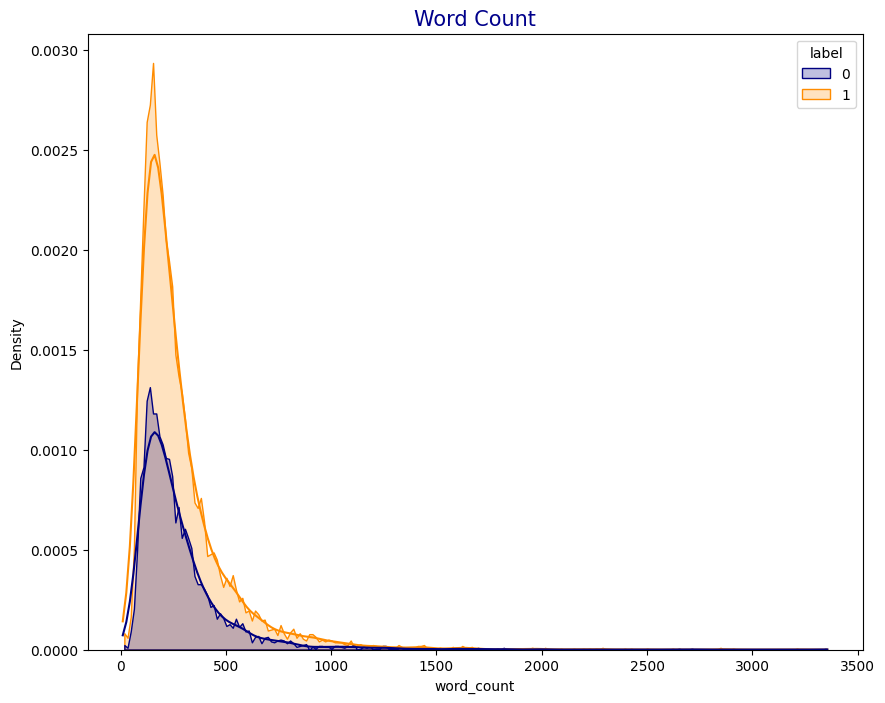

In [58]:
color=["navy","darkorange"]
plt.figure(figsize=(10,8))

sns.histplot(data=df2,x="word_count",palette=color,kde=True,hue="label",element="poly",stat="density")
plt.title("Word Count",fontsize=15,color="darkblue")
plt.show()

# Sentence Count

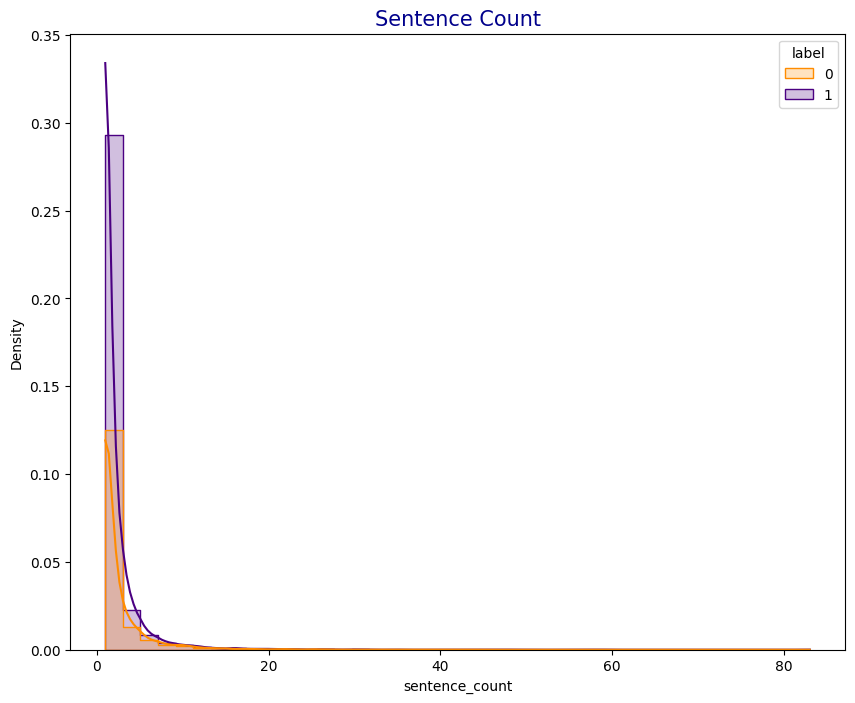

In [59]:
color=["darkorange","indigo"]
plt.figure(figsize=(10,8))
sns.histplot(data=df2,x="sentence_count",palette=color,kde=True,hue="label",element="step",stat="density",bins=40)
plt.title("Sentence Count",fontsize=15,color="darkblue")
plt.show()

In [60]:
df2.drop(columns=["character_count","word_count","sentence_count"],axis=1,inplace=True)

In [61]:
df2.head()

,text,label
0,৮ দিনে ১৮ বিল পাসদশম জাতীয় সংসদের মেয়াদ শেষ হয়...,0
1,আ’লীগের জনসভায় লোকে লোকারণ্য ফেনী ট্রাংক রোডএক...,0
2,মাদ্রাসায় জোড়া খুন পরিচালক তিন দিনের রিমান্ডেগ...,0
3,নেপালকে হারিয়ে গ্রুপ চ্যাম্পিয়ন বাংলাদেশসাফ অন...,1
4,কুড়িগ্রামে ২ শিক্ষার্থীর লাশ উদ্ধারকুড়িগ্রাম প...,1


In [62]:
avg_len=df2["text"].apply(len)
avg_len=avg_len.mean()
print(f"Average Text Length is : {avg_len:.2f}")

Average Text Length is : 1539.21


In [63]:
df1.head()

,text,label
0,henderson nev reuters u republican presidentia...,1
1,washington reuters president donald trump call...,1
2,well sad say sure chance next president belove...,0
3,simi valley calif reuters u arms industry read...,1
4,washington reuters president donald trump defe...,1


# Concat Bangla and English Data

In [64]:
df=pd.concat([df1, df2], ignore_index=True)

In [65]:
df.head()

,text,label
0,henderson nev reuters u republican presidentia...,1
1,washington reuters president donald trump call...,1
2,well sad say sure chance next president belove...,0
3,simi valley calif reuters u arms industry read...,1
4,washington reuters president donald trump defe...,1


In [66]:
df.to_csv("bangla_english_fake.csv",index=False)

In [67]:
df.shape

(24537, 2)

# Final sentence length

In [68]:
avg_len=df["text"].apply(len)
avg_len=avg_len.mean()
print(f"Average Text Length is : {avg_len:.2f}")

Average Text Length is : 1640.67


In [69]:
max_len=1600
text_list = df["text"].str.split().tolist()

In [70]:
import gensim
word2vec_model = gensim.models.Word2Vec(text_list, vector_size=100, window=5, min_count=1, workers=4, sg=1)

In [71]:
len(word2vec_model.wv.index_to_key)

261206

In [72]:
# word2vec_model.wv.key_to_index

In [73]:
word2vec_model.wv["রাজনীতি"] 

array([-0.11923598, -0.8883226 ,  0.03725814,  0.09179735, -0.8921057 ,
       -0.06808286,  0.2850629 ,  0.52976006,  0.28047508, -0.15674625,
       -0.31829908,  0.15420757, -0.1319528 , -0.00707869, -0.13507225,
       -0.36160943,  0.60531783, -0.52296704, -0.26525772, -0.17033221,
        0.03503807, -0.4067054 ,  0.40827018,  0.16041388, -0.24689913,
        0.31183487, -0.40485945,  0.36752802,  0.03213934, -0.1111733 ,
       -0.19686456,  0.67018247,  0.25313434, -0.22009133,  0.79197246,
        0.07352019,  0.05733156, -0.42398247, -0.10357168,  0.18119027,
       -0.37974396,  0.09646445, -0.42515242, -0.48834422,  0.10660065,
       -0.7243953 , -0.46700448, -0.0537874 ,  0.5657227 ,  0.44261667,
        0.05657869, -0.18536861, -0.05523377,  0.27632594, -0.20047674,
        0.07449523,  0.5081639 , -0.76050776, -0.6864672 , -0.51745164,
        0.50543743, -0.37667137, -0.13883327,  0.38082358, -0.19414888,
       -0.3483356 ,  0.42103988, -0.02027444,  0.0409863 ,  0.71

In [74]:
word2vec_model.wv["জরিমানা"] 


array([-0.3144508 ,  0.1116835 ,  0.52321637,  0.31721723, -0.02228766,
       -0.50428134,  0.20852463,  0.62717026, -0.27219105, -0.20945308,
       -0.29774815,  0.2152847 , -0.40101716, -0.06973156,  0.53184134,
       -0.32399097,  0.51995355, -0.6572426 , -0.2801092 , -0.18064272,
        0.45466664,  0.69111305, -0.08677632,  0.27062675, -0.91100776,
       -0.44762945, -0.87895423, -0.80558276, -0.38778472, -0.38885432,
        1.0280964 , -0.254037  ,  0.01640372, -0.3860944 ,  0.09028013,
       -0.19815564, -0.05208517, -0.895848  ,  0.20482293, -0.05111266,
       -0.77759784,  0.1645401 ,  0.08322506, -0.12789841, -0.0027132 ,
       -0.02786812,  0.90479916,  0.2564505 ,  0.12756205,  0.2346548 ,
       -0.04172575,  0.29089907, -0.09178804,  0.15880723, -0.01297558,
        0.12792389,  0.07767731, -0.22610882, -0.5666729 ,  0.49407634,
        0.78774244,  0.17018642, -0.4535965 , -0.48373216, -0.3809326 ,
       -0.3680536 ,  0.5480218 ,  0.39598557, -0.03955916, -0.70

In [75]:
word2vec_model.wv.most_similar('কলকাতা', topn=10)

[('মুম্বাই', 0.8378795981407166),
 ('ওমানের', 0.8208692669868469),
 ('চেন্নাই', 0.8158354163169861),
 ('ব্যাংকক', 0.8134647011756897),
 ('বোম্বে', 0.8104546070098877),
 ('কলকাতায়।', 0.8037137389183044),
 ('দিল্লি', 0.8018262386322021),
 ('বেঙ্গালুরুর', 0.8010575771331787),
 ('ঢাকায়।', 0.8005338311195374),
 ('গার্ডেন', 0.7989435195922852)]

In [76]:
word2vec_model.wv.most_similar("মৌসুমী", topn=10)

[('মৌসুমি', 0.7845973968505859),
 ('অক্ষের', 0.7586182951927185),
 ('জাহারা', 0.7425680160522461),
 ('বেঙ্গল', 0.7400615215301514),
 ('সায়ন্তিকা', 0.737519383430481),
 ('অ্যাটাক’', 0.7339270710945129),
 ('তমা', 0.7308506965637207),
 ('মিতু।', 0.728456974029541),
 ('রত্ন', 0.7272579669952393),
 ('চিরসবুজ', 0.7236136794090271)]

In [77]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(text_list)
text_seq=tokenizer.texts_to_sequences(text_list)
pad_seq=pad_sequences(text_seq,maxlen=max_len)
vocab_size=len(word2vec_model.wv.key_to_index)

In [78]:
# print(tokenizer.word_index)
# vocab_size=len(word2vec_model.wv.key_to_index)
# def get_weight_matrix(model):
#     weight_matrix = np.zeros((vocab_size, 100))
#     for word, i in word2vec_model.wv.key_to_index.items():
#         weight_matrix[i] = word2vec_model.wv[word]
#     return weight_matrix

# embedding_vector = get_weight_matrix(word2vec_model)

In [79]:
my_label=df["label"].values

In [80]:
X_train,X_test,Y_train,Y_test = train_test_split(pad_seq,my_label,test_size=0.2,random_state=42)

In [81]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dropout, Dense 
from keras.optimizers import Adam
learning_rate = 0.0001
embedding_dim=100
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,input_shape=(max_len,)))
model.add(LSTM(units=64, activation="tanh"))
model.add(Dropout(0.3))
model.add(Dense(units=1, activation='sigmoid'))
optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1600, 100)      │    26,120,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,162,905 (99.80 MB)

 Trainable params: 26,162,905 (99.80 MB)

 Non-trainable params: 0 (0.00 B)

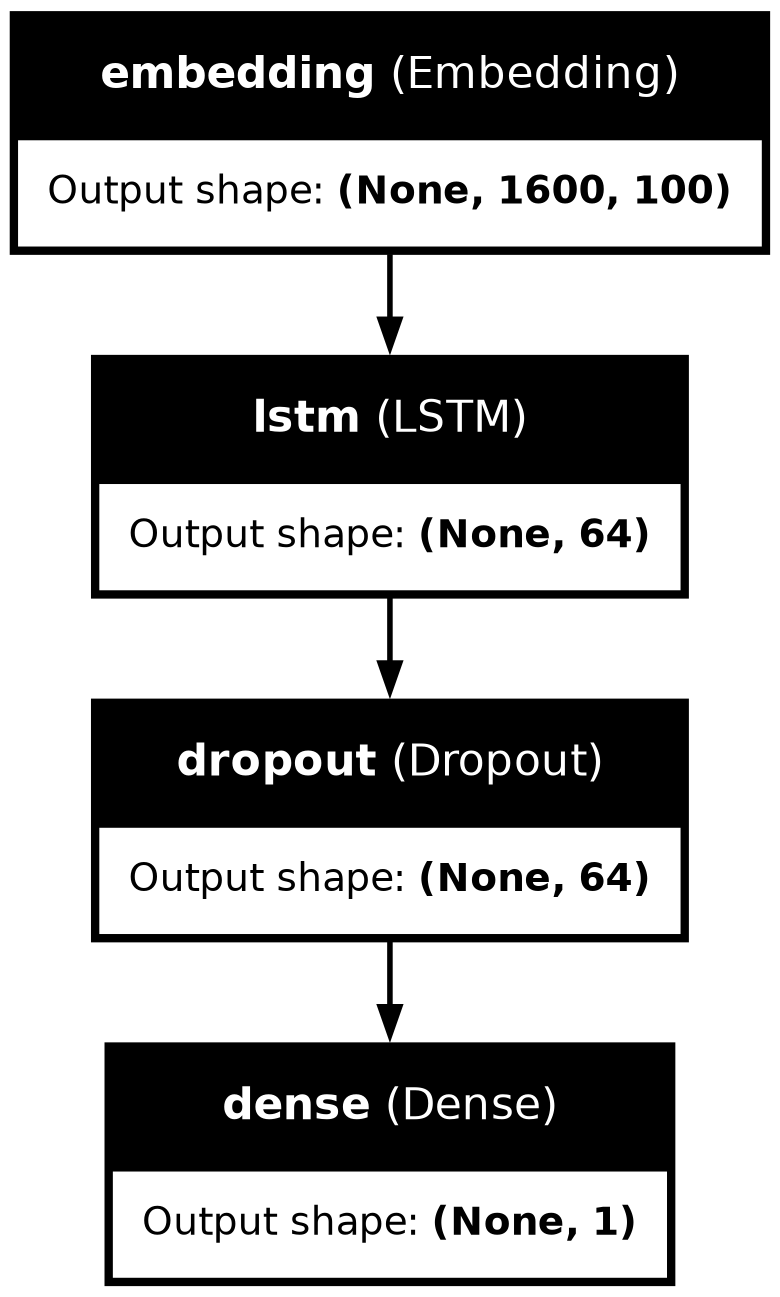

In [82]:
from keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [83]:
history=model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=10,batch_size=64)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.6428 - loss: 0.6449 - val_accuracy: 0.8270 - val_loss: 0.4247
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 92ms/step - accuracy: 0.8701 - loss: 0.3466 - val_accuracy: 0.8274 - val_loss: 0.3523
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9423 - loss: 0.1744 - val_accuracy: 0.8388 - val_loss: 0.3989
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9612 - loss: 0.1115 - val_accuracy: 0.8231 - val_loss: 0.3820
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9690 - loss: 0.0926 - val_accuracy: 0.8327 - val_loss: 0.4403
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9726 - loss: 0.0751 - val_accuracy: 0.8270 - val_loss: 0.4335
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9717 - loss: 0.0728 - val_accuracy: 0.8260 - val_loss: 0.4489
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - accuracy: 0.9756 - loss: 0.0632 - 

In [84]:

model.save("bangla_english_fake_model.h5")


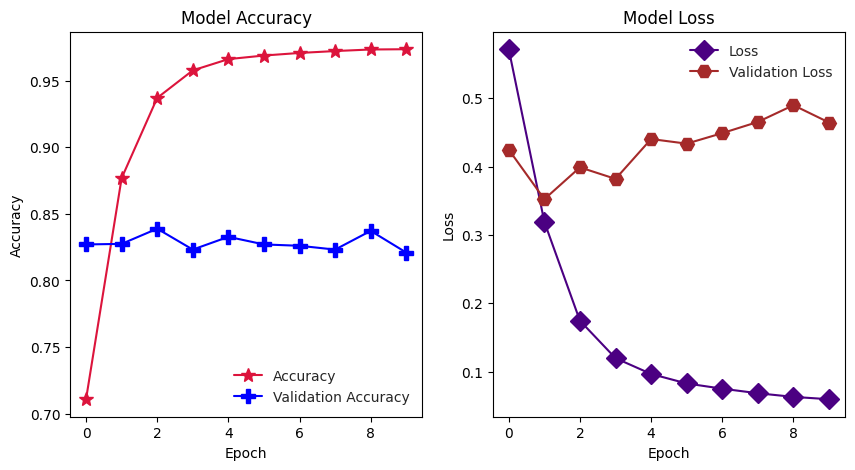

In [85]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
plt.style.use("seaborn-v0_8-dark")
# First subplot
ax[0].plot(history.history['accuracy'],label="Accuracy",color="crimson",marker="*",markersize=10)
ax[0].plot(history.history['val_accuracy'],label="Validation Accuracy",color="blue",marker="P",markersize=10)
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='best')

# Second subplot
ax[1].plot(history.history['loss'],label="Loss",color="indigo",marker="D",markersize=10)
ax[1].plot(history.history['val_loss'],label="Validation Loss",color="brown",marker="H",markersize=10)
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='best')

plt.show()


# Model Predict

In [86]:
pred=model.predict(X_test)
final_predict=(pred>=0.5).astype("int32")

154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


# receiver operating characteristic curve

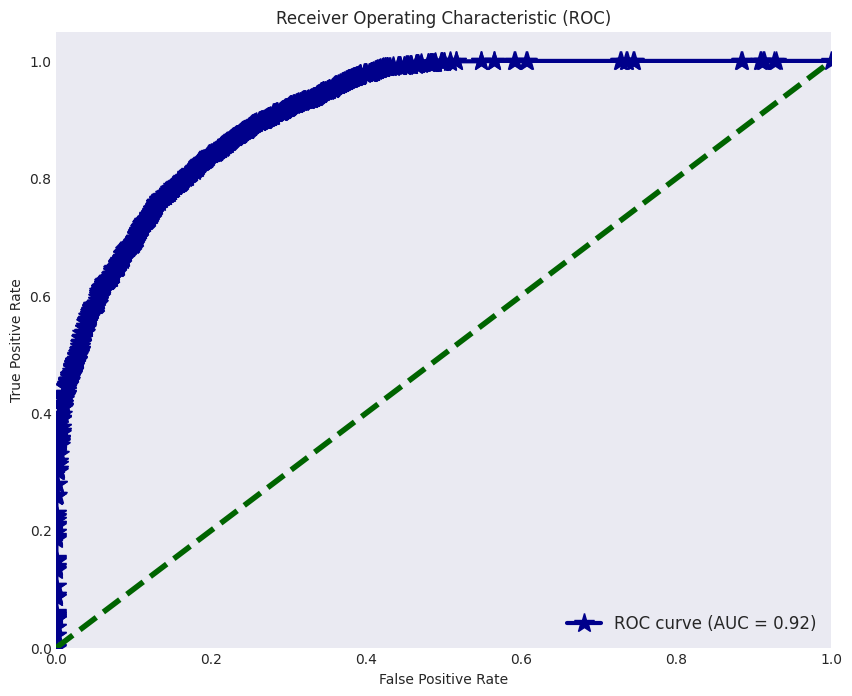

In [87]:

from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test,pred)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 8))
plt.style.use("seaborn-v0_8-dark")
plt.plot(fpr, tpr, color='darkblue', lw=3, label='ROC curve (AUC = %0.2f)' % roc_auc,marker="*",markersize=15)
plt.plot([0, 1], [0, 1], color='darkgreen', lw=4, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right",fontsize=12,edgecolor="black")
plt.show()

# Precision Recall Curve

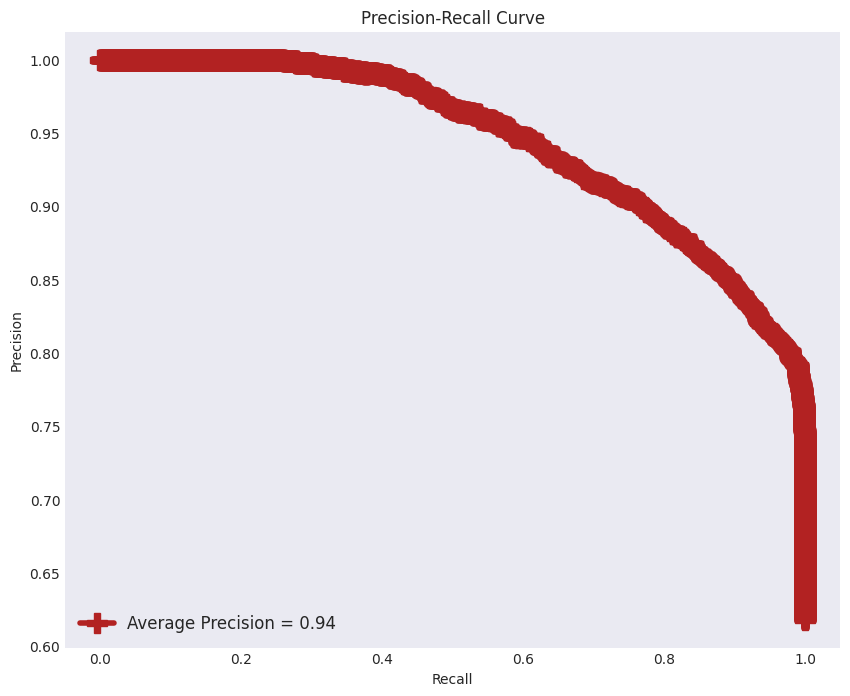

In [88]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(Y_test,pred)

ap_score = average_precision_score(Y_test,pred)
plt.figure(figsize=(10,8))
plt.style.use("seaborn-v0_8-dark")
plt.plot(recall, precision, color='firebrick', lw=4, label='Average Precision = %0.2f' % ap_score,marker="P",markersize=15)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left",fontsize=12,edgecolor="black")
plt.show()

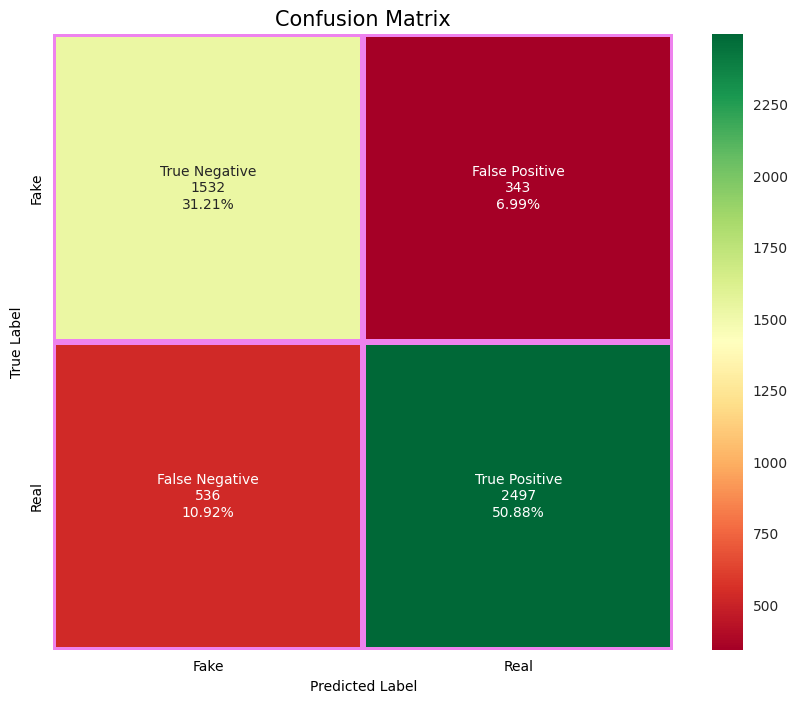

In [89]:
from sklearn.metrics import log_loss, cohen_kappa_score, matthews_corrcoef, brier_score_loss
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score,precision_score

label_name=["Fake","Real"]
my_matrix= confusion_matrix(Y_test, final_predict)
my_label = ["True Negative","False Positive","False Negative","True Positive"]
my_label_count=["{0:0.0f}".format(value) for value in my_matrix.flatten()]
percentage=["{0:.2%}".format(value) for value in my_matrix.flatten()/np.sum(my_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(my_label,my_label_count,percentage)]
labels=np.asarray(labels).reshape(2, 2)
# Plot confusion matrix as heatmap using Seaborn
plt.figure(figsize=(10,8))
plt.style.use("seaborn-v0_8-notebook")
sns.heatmap(my_matrix, annot=labels, cmap="RdYlGn", fmt="", cbar=True,
            xticklabels=label_name,yticklabels=label_name,lw=4,linecolor="violet")
plt.xlabel("Predicted Label",fontsize=10,color="black")
plt.ylabel("True Label",fontsize=10,color="black")
plt.title("Confusion Matrix",fontsize=15,color="black")
plt.xticks(fontsize=10,color="black")
plt.yticks(fontsize=10,color="black")
plt.show()

In [90]:
print(classification_report(Y_test,final_predict,target_names=label_name))

              precision    recall  f1-score   support

        Fake       0.74      0.82      0.78      1875
        Real       0.88      0.82      0.85      3033

    accuracy                           0.82      4908
   macro avg       0.81      0.82      0.81      4908
weighted avg       0.83      0.82      0.82      4908



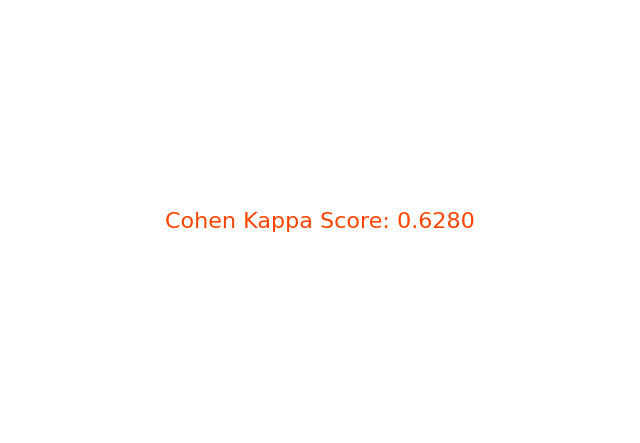

In [91]:
kappa = cohen_kappa_score(Y_test,final_predict)
plt.plot([])
plt.text(0,0, f'Cohen Kappa Score: {kappa:.4f}', fontsize=16, ha='center', va='center',color="orangered")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

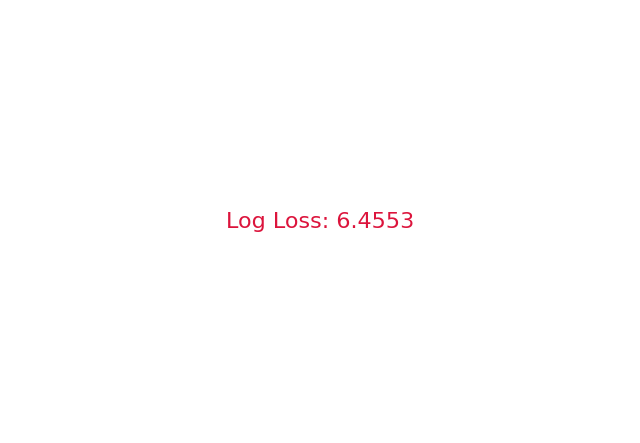

In [92]:
logarithm_loss=log_loss(Y_test,final_predict)
plt.plot([])
plt.text(0,0, f'Log Loss: {logarithm_loss:.4f}', fontsize=16, ha='center', va='center',color="crimson")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

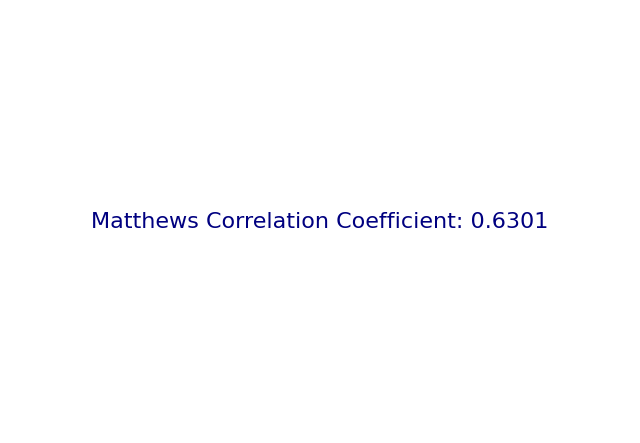

In [93]:
mcc = matthews_corrcoef(Y_test, final_predict)

plt.plot([])
plt.text(0,0, f'Matthews Correlation Coefficient: {mcc:.4f}', fontsize=16, ha='center', va='center',color="navy")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

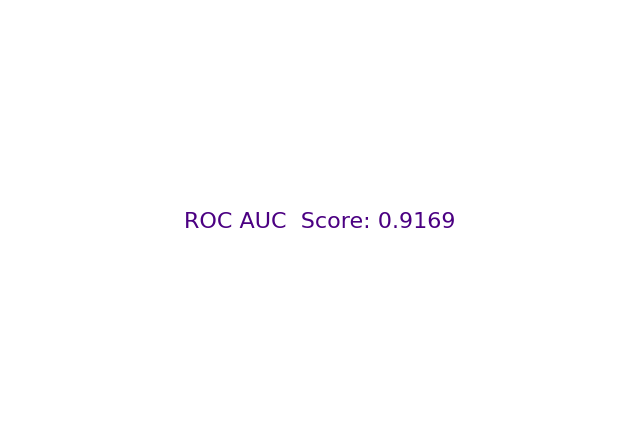

In [94]:
roc_auc = roc_auc_score(Y_test, pred)
plt.plot([])
plt.text(0,0, f'ROC AUC  Score: {roc_auc:.4f}', fontsize=16, ha='center', va='center',color="indigo")
plt.axis('off')


plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

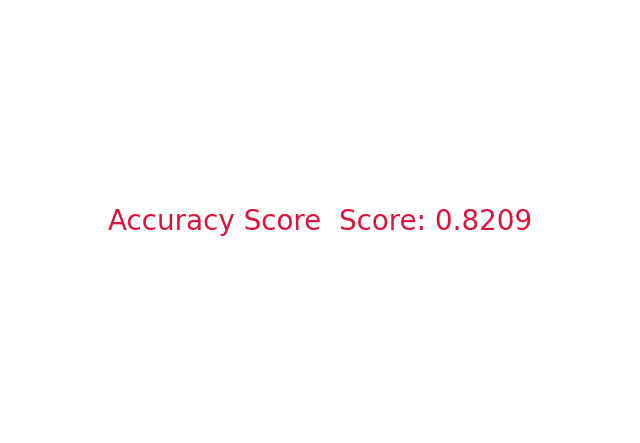

In [95]:
acc_score = accuracy_score(Y_test,final_predict)
plt.plot([])
plt.text(0,0, f'Accuracy Score  Score: {acc_score:.4f}', fontsize=20, ha='center', va='center',color="crimson")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

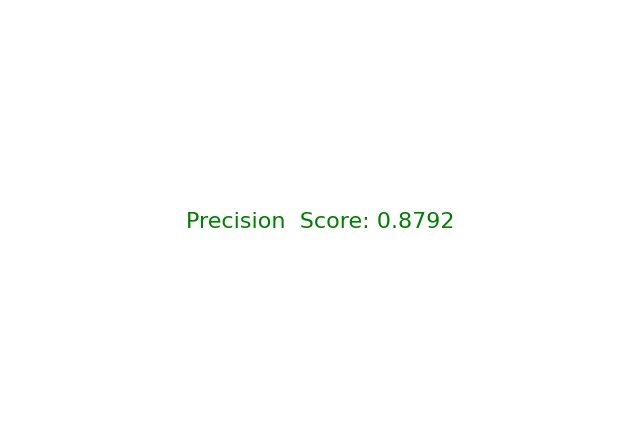

In [96]:
precision = precision_score(Y_test,final_predict)
plt.plot([])
plt.text(0,0, f'Precision  Score: {precision:.4f}', fontsize=16, ha='center', va='center',color="green")
plt.axis('off')


plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

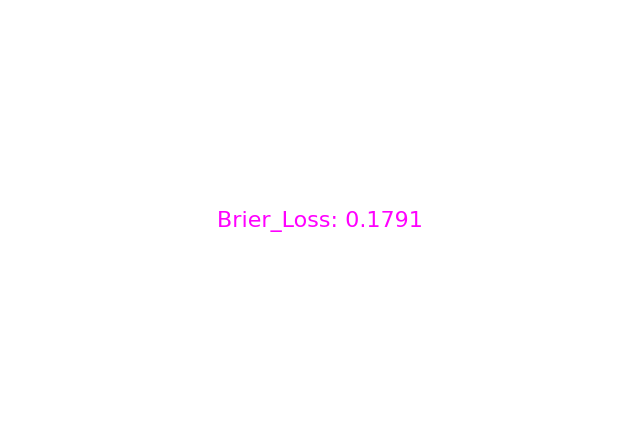

In [97]:
brier_loss = brier_score_loss(Y_test,final_predict)
plt.plot([])
plt.text(0,0, f'Brier_Loss: {brier_loss:.4f}', fontsize=16, ha='center', va='center',color="magenta")
plt.axis('off')


plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

# Custom Data Prediction

In [98]:

text = "রাজশাহীর পুঠিয়া উপজেলার একটি গ্রামে গতকাল সোমবার বৃষ্টির জন্য ব্যাঙের বিয়ে দেওয়া হয়েছে। দুপুর সাড়ে ১২টা থেকে বেলা সাড়ে ৩টা পর্যন্ত গ্রামের ৬০ থেকে ৭০টি বাড়িতে বৃষ্টির জন্য গান গাওয়া শেষে বিয়ের অনুষ্ঠান হয়। বিয়ে শেষে সন্ধ্যায় ছিল খাওয়াদাওয়ার আয়োজন।উপজেলার তাতারপুর গ্রামের ইউসুফ আলী ও হাবিবা খাতুন নামের দুই শিক্ষার্থীর উদ্যোগে এই বিয়ের অনুষ্ঠানের আয়োজন করা হয়।"
my_text_seq = tokenizer.texts_to_sequences([text])
my_text = pad_sequences(my_text_seq, maxlen=max_len)
my_pred = model.predict(my_text)

myfinal_pred = (my_pred >= 0.5).astype("int32")
if myfinal_pred == 0:
    print("News is Fake")
else:
    print("News is Real")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
News is Real


In [99]:

text = "৮ দিনে ১৮ বিল পাসদশম জাতীয় সংসদের মেয়াদ শেষ হয়ে যাচ্ছে। কার্যত অধিবেশনই রয়েছে বর্তমান সরকারের। অক্টোবরের মাঝামাঝিতে সংক্ষিপ্ত অধিবেশন ডেকেই \u200dইিত টানা সংসেদর। এরপর ডিসেম্বরের শেষ সপ্তাহে একাদশ সংসদ নির্বাচনের সংখ্যাগরিষ্ঠতা পাবেন তারাই সরকার গঠন করবেন। জানুয়ারিতে বসতে সরকারের অধিবেশন। বর্তমান সরকারের পাঁচ বছর পূর্ণ বছরের ২৮ জানুয়ারি। সংবিধান অনুযায়ী বিদ্যমান সংসদ ভেঙে দেওয়ার আগের ৯০ দিনের পরবর্তী সংসদ নির্বাচন কথা রয়েছে। হিসেবে অক্টোবর নির্বাচনের কাউনডাউন হবে। সরকারের মহলের আলোচনার পরিপ্রেক্ষিতে ধারণা হচ্ছে ২৮ অক্টোবরের মধ্য নির্বাচনকালীন সরকার গঠন হবে। সরকার রুটিন ওয়ার্ক করবে। দেশে উদ্বুদ্ধ পরিস্থিতির সৃষ্টি রাষ্ট্রপতি চাইলে যেকোনো সময় অধিবেশন আহ্বান পারেন। এদিকে দশম জাতীয় সংসদের ২২তম অধিবেশনটি রেকর্ডের খাতায় লেখা থাকবে। কেননা অধিবেশনের আট কার্যদিবসের ইতোমধ্যেই ১৪টি বিল পাস হয়ে শেষ দিনে চারটি পাস যাচ্ছে। হিসেবে অনন্য উচ্চতায় অধিবেশন। এতো অল্প সময়ে সংখ্যক বিল পাসের নজির নেই। গত ৯ সেপ্টেম্বর ২২তম অধিবেশন। ২০ সেপ্টেম্বর শেষ যাচ্ছে। শুক্রশনিবার বাদ দিয়ে টানা ১০ কার্যদিবস অধিবেশন চলে। বর্তমান সংসদের দু’জন সদস্যের মৃত্যুতে শোক প্রস্তাব গৃহীত হওয়ায় অন্যান্য সকল কার্যসূচি স্থগিত থাকে। তাছাড়া ১১ সেপ্টেম্বর বিদ্যুৎ বিপর্যয়ের কারণে এক ঘণ্টা অধিবেশন চালানোর স্থগিত হয়ে যায়। কারণে ১০ চললেও মূলত ৮ কার্যদিবসে কার্যক্রম পরিচালিত হয়। সংসদ সচিবালয়ের এক কর্মকর্তা বাংলানিউজকে বলেন এতো অল্প সময়ে এতোগুলো বিল পাস হয়েছে নেই। শেষ দিনেও চারটি বিল পাস হবে। সরকারের বিদায়ী বছরের অধিবেশনে কয়েকটি গুরুত্বপূর্ণ বিল পাস হয়। সাংবাদিকদের দাবি উপেক্ষা পাস ডিজিটাল নিরাপত্তা আইন। এছাড়া পাস সড়ক পরিবহন \u200cআইন। বাইরে কওমি মাদ্রাসাগুলোর দাবির পরিপ্রেক্ষিতে ‘কওমি মাদ্রাসাগুলোর দাওরায়ে হাদিসের সনদকে মাস্টার্স ডিগ্রি ইসলামিক স্টাডিজ আরবি সমমান আইন। তিনটি আইনের বিলই বুধবার ১৯ সেপ্টেম্বর পাস হয়েছে। বৃহস্পতিবার ২০ সেপ্টেম্বর সংসদ সচিবালয়ের কার্যসূচিতে চারটি বিল পাসের তালিকায় হয়েছে। রয়েছে জাতীয় ক্রীড়া পরিষদ বিল পণ্য উৎপাদনশীল রাষ্ট্রায়ত্ত শিল্প প্রতিষ্ঠান শ্রমিক চাকরি শর্তাবলী বিল বাংলাদেশ মুক্তিযোদ্ধা কল্যাণ ট্রাস্ট বিল কমিউনিটি ক্লিনিক স্বাস্থ্য সহায়তা বিল। এছাড়া ১৮ সেপ্টেম্বর পাস তিনটি বিল। সেগুলো হলো বাংলাদেশ কর্মচারী কল্যাণ বোর্ড সংশোধন বিল কৃষি বিপণন বিল জাতীয় দক্ষতা উন্নয়ন কর্তৃপক্ষ বিল। বাজেট অধিবেশনে ২৫ কার্যদিবসে বাজেট \u200dপাস ছাড়াও ১৪টি বিল পাস হয়। এবারের অধিবেশনে প্রধানমন্ত্রীর দু’টি কার্যদিবসে প্রশ্নোত্তর পর্ব ছিল। কার্যদিবসে প্রধানমন্ত্রীর দেওয়ার ৮৪টি প্রশ্ন পাওয়া যায়। প্রধানমন্ত্রী ২৬টি প্রশ্নের দেন। অন্যান্য মন্ত্রীদের এক ৫০৪টি প্রশ্ন পাওয়া যায়। মন্ত্রীরা ৮০৪টি প্রশ্নের দিয়েছেন। বাংলাদেশ সময় ১৫০০ ঘণ্টা সেপ্টেম্বর ২০ ২০১৮ এসএমটিএ"
my_text_seq = tokenizer.texts_to_sequences([text])
my_text = pad_sequences(my_text_seq, maxlen=max_len)
my_pred = model.predict(my_text)

myfinal_pred = (my_pred >= 0.5).astype("int32")
if myfinal_pred == 0:
    print("News is Fake")
else:
    print("News is Real")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
News is Fake


In [100]:
x=["Police arrested dozens of people at pro-Palestinian demonstrations at Yale University in Connecticut and New York University in Manhattan on Monday, as the war in Gaza continued to reverberate through US university campuses.The police crackdowns came after Columbia University canceled in-person classes on Monday in response to protesters setting up tent encampments at its New York City campus last week."]
my_text_seq=tokenizer.texts_to_sequences(x)
my_text=pad_sequences(my_text_seq,maxlen=max_len)
my_pred=model.predict(my_text)
myfinal_pred=(my_pred>=0.5).astype("int32")

if myfinal_pred==0:
    print("News is Fake")
else:
    print("News is Real")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
News is Real


In [101]:
x=["well sad say sure chance next president beloved united states america going donald trump disappointing say least country could actually elect man like however electoral college mostly spoken much point people america voted trump trying escape realize done vain escape mean fleeing canada large quantities successfully caused canada immigration crash right even unofficial results know something got ta give best part first time canada website crashed desperate americans super tuesday site crashed also google search move canada spiked significantly canada reputation nice nice responded advertisement test drive canada something big surprise despise mr trump would look toward friendly northern neighbours great healthcare welfare friendly obama forget maple syrup love one little problem everyone leaving though less people america still stand trump wants country us want stay thwart new orange president every chance get less us well less thwarted love america tempting might leave stay stand together let say screw trump together looks like lost popular vote fact people vote photo chip somodevilla getty images votes trump went canada immigration site went hard"]
my_text_seq=tokenizer.texts_to_sequences(x)
my_text=pad_sequences(my_text_seq,maxlen=max_len)
my_pred=model.predict(my_text)
myfinal_pred=(my_pred>=0.5).astype("int32")

if myfinal_pred==0:
    print("News is Fake")
else:
    print("News is Real")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
News is Fake
